# Notebook 9.1: Out-of-Sample Testing on the VIXY Tail Hedge

## Financial Trading with Python, 2nd Edition

---

In Chapter 8 we ran the VIXY tail hedge through both `bt` and VectorBT and produced our first proper backtest with realistic transaction costs and slippage. The numbers looked good. The Sharpe ratio was 0.95, the maximum drawdown was -20.55%, and the strategy beat SPY on a risk-adjusted basis over the full sample.

But there is a problem with that result, and it is the same problem that affects every backtest you will ever run. The strategy was developed on the same data that produced those numbers. The 90-day VIX moving average, the 10-day SPY realized volatility window, the 80/20 risk budget, the 20% cap on the VIXY allocation: none of these parameters were optimized in the way that produces overfit results, but all of them were chosen by someone (me) who had already looked at how SPY, BIL, VIXY, and VIX behave together. A backtest that uses the same data the strategy was developed on cannot tell us whether the strategy will work going forward. It can only tell us what happened on the path the strategy was built for.

This is why out-of-sample testing exists. The idea is simple. Split the data into two windows. Use the first window to develop the strategy. Run the strategy on the second window without changing anything, and see what happens. If the strategy holds up, you have your first real evidence that it has predictive content. If it falls apart, you have learned something important before you committed any capital.

In this notebook we apply that test to the VIXY tail hedge. We split the data at the start of 2022, build the strategy on the pre-2022 window, and run it on the post-2022 window. We then compare the two results honestly and ask what we have actually learned.

I want to be direct about one thing up front. A clean OOS test is the minimum honest standard for evaluating a strategy. It is not the bar a practitioner should clear before committing capital to a real allocation. Six years of test data is not a track record. We will return to this point at the end of the notebook, and it is the bridge into the walk-forward analysis we cover in Notebook 9.2.

This notebook covers:

- Splitting time-series data correctly for out-of-sample testing
- Common data leakage pitfalls and how to avoid them
- Running the VIXY tail hedge through VectorBT on the training and test windows
- The three failure explanations for a bad OOS result and why a single test cannot distinguish them
- Why six years of test data is not enough for a real allocation decision

We use the following packages in this notebook:

- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualization
- `vectorbt` for backtesting, following the same pattern from Notebook 8.2
- The `calculate_performance_metrics` function from `functions.py`, our authoritative metrics toolkit from Chapter 7

## Section 1: Setting Up the Environment

We start by installing VectorBT and importing the libraries we need. The setup is identical to Notebook 8.2 so the workflow stays consistent. We also load `functions.py` from the GitHub repository so we have access to `calculate_performance_metrics` for the authoritative performance numbers at the end.

In [1]:
# Install pinned package versions. Same versions used in Chapter 8 so the
# environment stays consistent across the book. We only install packages
# Colab does not already provide at the right version, plus VectorBT.
!pip install vectorbt==0.28.5 pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.3 -q

# Download the Chapter 7 metrics toolkit. We use the same authoritative
# performance evaluation function we built in Notebook 7.1 and reused
# throughout Chapters 7 and 8. Keeping the toolkit independent of the
# backtesting library is one of the core principles from Chapter 8:
# the backtester's job is to simulate trading, the toolkit's job is to
# measure what happened, and we never let the two get tangled together.
!wget -q https://raw.githubusercontent.com/gowripackt/Hands-on-Financial-Trading-with-Python-Second-Edition/main/functions.py

# Download the case study data. This parquet file was built in Chapter 4
# and contains FMP-sourced adjusted close prices for SPY, BIL, VIXY, and VIX.
# Adjusted close is the input that makes synthesized prices safe for VIXY,
# as we established in Chapter 8.
!wget -q https://raw.githubusercontent.com/gowripackt/Hands-on-Financial-Trading-with-Python-Second-Edition/main/case_study_prices.parquet

# Standard imports. Same pattern as every other notebook in the book.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# VectorBT does most of its work through this single namespace. The
# alias is the convention used in the official VectorBT documentation.
import vectorbt as vbt

# The Chapter 7 performance toolkit. calculate_performance_metrics
# takes a return series and produces our authoritative metrics:
# CAGR, annualized volatility, Sharpe, max drawdown, hit rate, etc.
from functions import calculate_performance_metrics

# Suppress pandas FutureWarnings that VectorBT triggers on some pandas
# versions. The warnings are noise, not signal, and they clutter the
# notebook output.
warnings.simplefilter(action='ignore', category=FutureWarning)

# Standard plotting setup, same as every previous notebook.
sns.set_theme()

# Confirm the environment is ready.
print(f"pandas version:    {pd.__version__}")
print(f"numpy version:     {np.__version__}")
print(f"vectorbt version:  {vbt.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.7/421.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.2 MB/s eta 0:00:00
pandas version:    2.2.2
numpy version:     2.0.2
vectorbt version:  0.28.5


The environment is ready. Pandas, numpy, and vectorbt are pinned to the same versions we used in Chapter 8, so any backtest result we produce here can be compared directly against the Chapter 8 numbers without worrying about library-version drift. The matplotlib, seaborn, and scipy installs were silent, which means the pinned versions installed cleanly. We are now set up to load the case study data and define the train/test split.

## Section 2: Loading the Data and Defining the Split

We load the case study parquet and define the train/test split at the start of 2022. The split point is a deliberate choice. The training window covers 2011 through the end of 2021, which includes the COVID volatility shock of 2020. That event is the single most important hedge moment in the strategy's lifetime, and keeping it in training is the honest call. The test window covers 2022 onward, which gives us a real bear market (the 2022 rate-driven drawdown), the subsequent recovery, and the elevated rate environment that followed.

Before we touch the strategy logic, we visualize the split so we can see exactly what each window contains.

In [2]:
# Load the case study price data. This was prepared in Chapter 4 and
# contains adjusted close prices for SPY, BIL, VIXY, and VIX (the index)
# from January 2011 onward. Adjusted close is what makes synthesized
# prices safe for VIXY, per the Chapter 8 rule.
df_prices = pd.read_parquet('case_study_prices.parquet')

# Define the split date. We use January 1, 2022 as the cutoff. The
# training window is everything before this date; the test window is
# everything from this date onward. We split chronologically because
# time-series data must never be split randomly: a random split would
# allow the strategy to "see" future information during training,
# which is the most direct form of lookahead bias possible.
split_date = '2022-01-01'

# Build the train and test slices. The training slice ends at the last
# trading day before the split. The test slice starts at the split date
# and runs to the end of the data.
df_train = df_prices.loc[:split_date].iloc[:-1]
df_test  = df_prices.loc[split_date:]

# Confirm the split looks right.
print("Full sample:")
print(f"  {df_prices.index.min().date()} to {df_prices.index.max().date()}, "
      f"{len(df_prices):,} trading days")
print()
print("Training window:")
print(f"  {df_train.index.min().date()} to {df_train.index.max().date()}, "
      f"{len(df_train):,} trading days, "
      f"{len(df_train)/252:.1f} years")
print()
print("Test window:")
print(f"  {df_test.index.min().date()} to {df_test.index.max().date()}, "
      f"{len(df_test):,} trading days, "
      f"{len(df_test)/252:.1f} years")

Full sample:
  2011-01-04 to 2025-12-31, 3,771 trading days

Training window:
  2011-01-04 to 2021-12-30, 2,767 trading days, 11.0 years

Test window:
  2022-01-03 to 2025-12-31, 1,003 trading days, 4.0 years


The split is clean. The training window holds 11 years of data (2,767 trading days) and the test window holds 4 years (1,003 trading days). That is roughly a 73/27 split by length, close to the 70/30 we targeted. The training window contains the full pre-2022 history including the COVID volatility shock; the test window contains the 2022 drawdown, the 2023 to 2024 recovery, and the higher-rate environment that defined the period.

Four years of test data is short. I want to flag that now and we will come back to it at the end of the notebook. A clean OOS test on four years of data tells you something useful. It does not tell you enough to commit capital to a real allocation. That distinction is the bridge into the walk-forward analysis we cover in Notebook 9.2.

Before we run any strategy logic, we visualize the split so the regime context of each window is in plain sight.

### 2.1 Visualizing the Split

We plot SPY and VIX side by side with the train and test windows shaded. SPY shows us the equity backdrop. VIX shows us the volatility regime, which is what the strategy actually responds to. Looking at both together makes it obvious what stress events live in each window and what the strategy will be asked to handle on the test side.

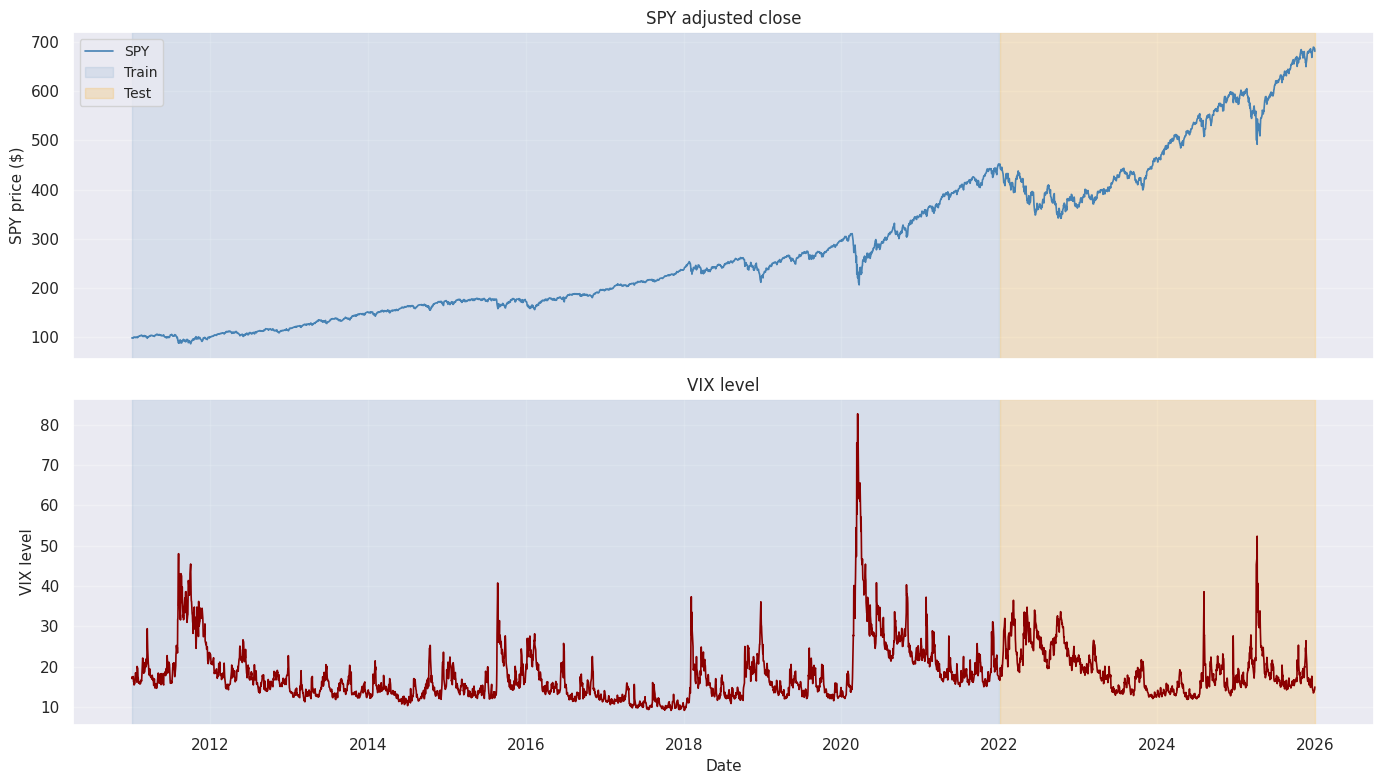

In [3]:
# Plot SPY price and VIX level on stacked subplots, with the train and
# test windows shaded. The point of this view is to make the regime
# context of each window obvious before we run any backtest results.
# A reader looking at this chart should immediately see what stress
# events the strategy was developed against and what stress events
# the test window will hold it accountable for.

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: SPY adjusted close. The equity backdrop.
axes[0].plot(df_prices.index, df_prices['SPY'],
             color='steelblue', linewidth=1.2, label='SPY')
axes[0].set_ylabel('SPY price ($)', fontsize=11)
axes[0].set_title('SPY adjusted close', fontsize=12)

# Bottom panel: VIX level. This is what the strategy reads to decide
# whether to put on the tail hedge.
axes[1].plot(df_prices.index, df_prices['^VIX'],
             color='darkred', linewidth=1.2, label='VIX')
axes[1].set_ylabel('VIX level', fontsize=11)
axes[1].set_title('VIX level', fontsize=12)
axes[1].set_xlabel('Date', fontsize=11)

# Shade the training window in light blue and the test window in light
# orange across both panels. We use the actual first and last dates of
# each window so the shading exactly matches the slices we built.
for ax in axes:
    ax.axvspan(df_train.index.min(), df_train.index.max(),
               alpha=0.12, color='steelblue', label='Train')
    ax.axvspan(df_test.index.min(), df_test.index.max(),
               alpha=0.18, color='orange', label='Test')
    ax.grid(True, alpha=0.3)

# Single legend in the top panel to avoid clutter.
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

The chart makes the regime asymmetry between the two windows obvious. The training window holds the COVID volatility shock of March 2020, where VIX spiked above 80, the largest single-day VIX print in modern history. It also holds the August 2015 China devaluation spike, the February 2018 volmageddon event, and the late 2018 growth scare. The training window saw four meaningful volatility regimes and the strategy was developed against all of them.

The test window is quieter on the VIX side. The 2022 drawdown shows up clearly in SPY but the VIX response was muted, peaking around 35 rather than the 50-plus prints of the training-window stress events. The April 2025 spike is visible. Outside those two events, VIX spent most of the test period in the teens and low twenties, which is a benign volatility regime by the standards of the training window.

This matters for how we interpret the OOS result. The VIXY tail hedge is designed to add value when volatility is elevated. If the test window does not have much elevated volatility to work with, a flat or modestly positive OOS result is consistent with the strategy doing exactly what it was designed to do, which is sit mostly in 80/20 SPY/BIL when there is nothing to hedge against. We need to keep this in mind when we read the test-window numbers. A bad OOS result on a quiet test window does not necessarily mean the strategy is broken. It might mean the test window did not give the strategy anything to do.

This is the regime ambiguity problem. We will return to it explicitly after we see the results.

## Section 3: Data Leakage Pitfalls

Three things can quietly invalidate an out-of-sample test. None of them produce an error message. The test runs, the numbers print, and the result looks meaningful even when it is not. We name them here so we can recognize them.

### 3.1 Full-Sample Normalization

Any statistic used to build a feature must be computed only from data available at the time the feature is calculated. The most common mistake is computing a rolling z-score, a normalization, or a PCA loading on the full price history before splitting. The full-sample mean contains information from the test window, and that information silently leaks into the training-window features.

The fix: compute features inside each window using only data available within that window.

For our VIXY tail hedge, this raises one practical question. The 90-day VIX moving average needs a 90-day warmup before it produces a valid value. We can either compute the test-window MA from test-window data only (the strict version, which leaves the first 90 days of the test window with no signal) or seed the test-window MA from the last 90 days of training-window data (the carry-forward version, which has the strategy fully active from day one of the test).

We use the carry-forward version. A real practitioner launching this strategy on January 1, 2022 would not throw away three months of recent VIX data and wait for the moving average to wake up. They would initialize from the most recent prior data and trade from day one. The strict version is more academically pure; the carry-forward version is what actually gets implemented. We choose realism here.

### 3.2 Peeking at Test Data to Guide Research

This one happens in your head, not in the code. You build a strategy on training. You run the OOS test. The result is poor. You go back, add a feature that would have handled the regime that hurt you, and rerun. The test looks better.

The strategy is now contaminated. You used the test window to inform a design decision, even though no test-window data passed through any line of code. The next OOS test on the same data tells you nothing new because the strategy has been shaped by what you saw the first time.

The fix is procedural. Once the split is set, commit to it. Run the test once. Accept the result.

### 3.3 Re-splitting After a Bad Result

The OOS result comes back bad. Instead of accepting it, you change the split. A few months earlier. A different ratio. Exclude an "unusual" period.

Whatever the change, the new split was chosen because it produced a better number. The new test is no longer a fair test of the strategy; it is a test of which split makes the strategy look best. This is one of the most common forms of soft data snooping in quantitative finance and it is the hardest to resist when you have spent weeks on a strategy that just failed.

The fix is the same as 3.2. Commit to the split before running the test. If the strategy fails, the strategy is unproven. Decide what to do next on its merits, but do not change the split to find a better number.

## Section 4: Building the VIXY Tail Hedge with the Carry-Forward Warmup

We now build the VIXY tail hedge weights, applying the carry-forward warmup we discussed in Section 3.1. The strategy logic is identical to the version from Notebook 8.2: a 90-day VIX moving average, a 10-day SPY realized volatility window, an 80% SPY allocation when no hedge is on, and a VIXY allocation sized by VIX/100 capped at 20% when the hedge signal fires.

The carry-forward warmup means we compute features on the full price history first, then split the resulting weight DataFrame at the split date. The first 90 days of the test window have moving averages seeded from training-window VIX values, which is the practitioner-realistic version. The strategy is fully active from day one of the test window.

We wrap the weight construction in a function so the same logic produces the training and test weights without duplication.

In [4]:
def calculate_vixy_weights(df_prices,
                           sma_period=90,
                           std_period=10,
                           risky_portion=0.80,
                           vixy_cap=0.20):
    """
    Calculate daily target weights for the VIXY tail hedge strategy.

    This is the inline signal construction from Notebook 8.2, refactored
    into a function so it can be called repeatedly without duplication
    (Notebook 9.2 will use the same function inside the walk-forward
    loop). The calculations are identical to 8.2: signal, allocation,
    cap, warmup trim, and column order.

    The strategy holds a constant SPY allocation. The remaining defensive
    sleeve sits in BIL by default and shifts into VIXY when SPY's 10-day
    annualized realized volatility exceeds the VIX simple moving average.
    The VIXY allocation is sized by VIX/100, capped at vixy_cap, with
    the BIL allocation absorbing the remainder.

    Parameters
    ----------
    df_prices : DataFrame
        Daily adjusted close prices with columns SPY, BIL, VIXY, ^VIX.
    sma_period : int
        Lookback window for the VIX simple moving average. Default 90.
    std_period : int
        Lookback window for SPY realized volatility. Default 10.
    risky_portion : float
        Constant SPY allocation. Default 0.80.
    vixy_cap : float
        Maximum VIXY allocation when the hedge signal is on. Default 0.20.

    Returns
    -------
    DataFrame with columns [SPY, BIL, VIXY] containing daily target
    weights, trimmed to the first date where both lookbacks are valid.
    """
    # Build the VIXY signal on the full price history. Identical to the
    # inline pattern from Notebook 8.2.
    vix = df_prices['^VIX'].copy()
    vix_sma = vix.rolling(window=sma_period).mean()
    spy_returns = df_prices['SPY'].pct_change()
    spy_realized_vol = (spy_returns.rolling(window=std_period).std()
                        * np.sqrt(252) * 100)

    # Signal: hedge ON when realized vol > VIX SMA.
    signal_on = spy_realized_vol > vix_sma

    # VIXY allocation: VIX/100, capped at vixy_cap, when the signal fires.
    vixy_alloc = np.where(signal_on, np.minimum(vix / 100, vixy_cap), 0.0)

    # Find the strategy start date. The binding constraint is whichever
    # lookback warms up later (the 90-day VIX SMA, in the default case).
    start_date = max(
        vix_sma.first_valid_index(),
        spy_realized_vol.first_valid_index()
    )

    # Build the full daily weight DataFrame. SPY is constant at the
    # risky portion; the defensive sleeve splits between BIL and VIXY.
    df_weights = pd.DataFrame(index=df_prices.index)
    df_weights['SPY']  = risky_portion
    df_weights['BIL']  = (1.0 - risky_portion) - vixy_alloc
    df_weights['VIXY'] = vixy_alloc

    # Trim to the strategy start date. The warmup period is excluded.
    df_weights = df_weights.loc[start_date:]

    return df_weights


def to_sparse_weights(df_weights):
    """
    Convert a daily weights DataFrame to the sparse format VectorBT
    expects: weights on dates where allocation changes, NaN elsewhere.

    The first row is forced to be a rebalance so the initial portfolio
    is set correctly. This matches the sparse construction from
    Notebook 8.2.
    """
    changes = (df_weights != df_weights.shift(1)).any(axis=1)
    changes.iloc[0] = True
    return df_weights.where(changes)


# Build the full-sample daily weights using the canonical function.
# Computing on the full sample is what implements the carry-forward
# warmup we discussed in Section 3.1.
df_weights_full = calculate_vixy_weights(df_prices)

# Split the daily weights into train and test windows.
df_weights_train = df_weights_full.loc[:split_date].iloc[:-1]
df_weights_test  = df_weights_full.loc[split_date:]

# Convert each window to the sparse format VectorBT expects.
df_weights_train_sparse = to_sparse_weights(df_weights_train)
df_weights_test_sparse  = to_sparse_weights(df_weights_test)

# Trim actual adjusted close prices to each window. We use actual prices
# from the parquet, the mandatory choice for VIXY (Notebook 8.2 Section
# 4.1): synthesizing from raw returns would compound contango decay into
# a series that approaches zero and break share-quantity calculations.
df_prices_train = df_prices[['SPY', 'BIL', 'VIXY']].loc[df_weights_train.index].copy()
df_prices_test  = df_prices[['SPY', 'BIL', 'VIXY']].loc[df_weights_test.index].copy()

# Confirm the slices are aligned and the warmup was removed.
print(f"Strategy start date: {df_weights_full.index.min().strftime('%Y-%m-%d')}")
print()
print(f"Training window:")
print(f"  {df_weights_train.index.min().date()} to {df_weights_train.index.max().date()}")
print(f"  {len(df_weights_train):,} trading days, "
      f"{df_weights_train_sparse.notna().any(axis=1).sum():,} rebalance dates")
print()
print(f"Test window:")
print(f"  {df_weights_test.index.min().date()} to {df_weights_test.index.max().date()}")
print(f"  {len(df_weights_test):,} trading days, "
      f"{df_weights_test_sparse.notna().any(axis=1).sum():,} rebalance dates")
print()
print("Training sparse weights (first 5 rows):")
print(df_weights_train_sparse.head(5))

Strategy start date: 2011-05-12

Training window:
  2011-05-12 to 2021-12-30
  2,678 trading days, 377 rebalance dates

Test window:
  2022-01-03 to 2025-12-31
  1,003 trading days, 97 rebalance dates

Training sparse weights (first 5 rows):
            SPY  BIL  VIXY
Date                      
2011-05-12  0.8  0.2   0.0
2011-05-13  NaN  NaN   NaN
2011-05-16  NaN  NaN   NaN
2011-05-17  NaN  NaN   NaN
2011-05-18  NaN  NaN   NaN


The function returns a clean weight series starting on 2011-05-12, the first trading day on which the 90-day VIX moving average has warmed up. The training window holds 2,678 trading days with 377 rebalance dates, and the test window holds 1,003 trading days with 97 rebalance dates. The first training row shows 0.8 / 0.2 / 0.0, which is the no-hedge allocation, confirming that on the first valid day the signal was off and the strategy correctly defaulted to 80% SPY and 20% BIL.

The sparse weight format is what VectorBT expects. Real values appear on dates where the target allocation changes; NaN appears on dates where the previous allocation persists. VectorBT interprets NaN as hold and forward-fills the prior weights internally. This is the same sparse pattern from Notebook 8.2 and matches the production backtesting approach.

We are now ready to run the backtest on each window.

## Section 5: Running the Training-Window Backtest

We run the VectorBT backtest on the training window using the same configuration from Notebook 8.2: monthly rebalancing, target-percent sizing, cash sharing across the three assets, and small but realistic transaction costs. We extract the daily return series from the VectorBT portfolio object and feed it through the Chapter 7 metrics toolkit for the authoritative performance numbers.

We run SPY buy-and-hold on the same training window as a benchmark. Without a benchmark, the strategy numbers are just numbers. With one, we can answer the question that actually matters: did the strategy add value relative to the obvious alternative.

In [5]:
# Configure the backtest. These are the same parameters from Notebook
# 8.2: 5 basis points of transaction costs (fees), 5 basis points of
# slippage on each trade, monthly rebalancing implicit in the sparse
# weight DataFrame, and cash_sharing across the three assets so the
# weights are interpreted as a unified portfolio.
fees     = 0.0005   # 5 bps per trade
slippage = 0.0005   # 5 bps per trade

# Run the strategy on the training window using the actual adjusted
# close prices and the sparse training weights.
pf_train = vbt.Portfolio.from_orders(
    close       = df_prices_train,            # actual adjusted close prices
    size        = df_weights_train_sparse,    # sparse target weights
    size_type   = 'targetpercent',            # weights interpreted as targets
    group_by    = True,                       # treat the three assets as one portfolio
    cash_sharing = True,                      # share cash across the three assets
    call_seq    = 'auto',                     # let VectorBT order trades sensibly
    fees        = fees,
    slippage    = slippage,
    freq        = '1D'
)

# Extract the daily return series from the portfolio. This is the
# return stream we feed to the Chapter 7 metrics toolkit.
strategy_returns_train = pf_train.returns()

# Build the SPY buy-and-hold benchmark on the same training window.
# 100% SPY allocation, same fees and slippage, same engine. We use
# a single-row sparse weight DataFrame: one allocation on day one,
# held forever, no rebalancing.
df_bench_weights_train = pd.DataFrame(
    np.nan,
    index=df_prices_train.index,
    columns=['SPY']
)
df_bench_weights_train.iloc[0] = 1.0

pf_bench_train = vbt.Portfolio.from_orders(
    close       = df_prices_train[['SPY']],
    size        = df_bench_weights_train,
    size_type   = 'targetpercent',
    group_by    = True,
    cash_sharing = True,
    call_seq    = 'auto',
    fees        = fees,
    slippage    = slippage,
    freq        = '1D'
)

benchmark_returns_train = pf_bench_train.returns()

# Run both return streams through the Chapter 7 metrics toolkit. This
# is the authoritative source of performance numbers, not VectorBT's
# built-in stats. Same convention as every previous notebook.
metrics_strategy_train = calculate_performance_metrics(strategy_returns_train)
metrics_bench_train    = calculate_performance_metrics(benchmark_returns_train)

# Build a comparison table.
df_train_results = pd.DataFrame({
    'VIXY tail hedge': metrics_strategy_train,
    'SPY buy-and-hold': metrics_bench_train
})

print("Training-window performance (2011-05-12 to 2021-12-30):")
print()
print(df_train_results.round(4))

Training-window performance (2011-05-12 to 2021-12-30):

                        VIXY tail hedge SPY buy-and-hold
Total Return                    194.11%          333.55%
Ann. Return (CAGR)               10.68%           14.80%
Ann. Volatility                  11.68%           17.00%
Downside Deviation                8.12%           12.21%
Max Drawdown                    -17.45%          -33.72%
Max DD Duration (days)              203              187
Ulcer Index                       3.839            4.900
Sharpe Ratio                      0.915            0.871
Sortino Ratio                     1.317            1.212
Calmar Ratio                      0.612            0.439
Ulcer Performance Index           2.783            3.021
Win Rate (monthly)                68.0%            70.3%
Profit Factor                      2.42             2.28
Avg Win/Loss                       1.14             0.96


The training-window result is consistent with what we saw on the full sample in Chapter 8. The strategy delivered a 10.68% CAGR with 11.68% volatility, against SPY buy-and-hold at 14.80% CAGR with 17.00% volatility. The strategy left 412 basis points of annual return on the table relative to SPY, but it gave back roughly a third of the volatility and cut the maximum drawdown nearly in half (-17.45% versus -33.72%). The risk-adjusted metrics tell the cleaner story. The Sharpe ratio of 0.915 edges out SPY's 0.871, the Sortino of 1.317 beats 1.212, and the Calmar of 0.612 is meaningfully better than 0.439.

This is exactly the profile a tail hedge is designed to deliver. The strategy will not beat the market on raw return because it is structurally underweight equity by 20%. The value proposition is in delivering smoother returns and shallower drawdowns, and the training-window numbers confirm the strategy did that on the data it was developed against.

But the training-window result is not the test. The strategy was developed knowing what was in this period. The COVID volatility shock, the late 2018 growth scare, the February 2018 volmageddon event, the August 2015 China devaluation: the parameter choices around the 90-day MA, the 10-day realized vol, and the 20% VIXY cap were all made by someone who had seen these events. The training-window numbers tell us the strategy is not broken on the data it was built for, which is the minimum bar. Whether it has any predictive content beyond that is the question the test window is going to answer.

### 5.1 Running the Test-Window Backtest

We now run the same backtest configuration on the test window. Same fees, same slippage, same engine, same metrics toolkit. The only thing that changes is the data feeding in. This is the discipline that makes an OOS test meaningful: nothing about the strategy or the evaluation gets adjusted between the two runs. The training and test results are produced by the same machinery on different slices of the same world.

In [6]:
# Run the strategy on the test window. Same parameters as the
# training-window backtest. The only thing that changes is the
# data feeding in: actual adjusted close prices and sparse weights
# from the test slice.
pf_test = vbt.Portfolio.from_orders(
    close        = df_prices_test,
    size         = df_weights_test_sparse,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = '1D'
)

strategy_returns_test = pf_test.returns()

# Build the SPY buy-and-hold benchmark on the same test window.
df_bench_weights_test = pd.DataFrame(
    np.nan,
    index=df_prices_test.index,
    columns=['SPY']
)
df_bench_weights_test.iloc[0] = 1.0

pf_bench_test = vbt.Portfolio.from_orders(
    close        = df_prices_test[['SPY']],
    size         = df_bench_weights_test,
    size_type    = 'targetpercent',
    group_by     = True,
    cash_sharing = True,
    call_seq     = 'auto',
    fees         = fees,
    slippage     = slippage,
    freq         = '1D'
)

benchmark_returns_test = pf_bench_test.returns()

# Run both return streams through the Chapter 7 metrics toolkit.
metrics_strategy_test = calculate_performance_metrics(strategy_returns_test)
metrics_bench_test    = calculate_performance_metrics(benchmark_returns_test)

# Build the test-window comparison table.
df_test_results = pd.DataFrame({
    'VIXY tail hedge': metrics_strategy_test,
    'SPY buy-and-hold': metrics_bench_test
})

print("Test-window performance (2022-01-03 to 2025-12-31):")
print()
print(df_test_results.round(4))

Test-window performance (2022-01-03 to 2025-12-31):

                        VIXY tail hedge SPY buy-and-hold
Total Return                     23.15%           50.76%
Ann. Return (CAGR)                5.37%           10.86%
Ann. Volatility                  12.78%           18.00%
Downside Deviation                8.88%           12.44%
Max Drawdown                    -21.75%          -24.50%
Max DD Duration (days)              516              488
Ulcer Index                       9.756            9.390
Sharpe Ratio                      0.420            0.603
Sortino Ratio                     0.605            0.873
Calmar Ratio                      0.247            0.444
Ulcer Performance Index           0.550            1.157
Win Rate (monthly)                58.3%            64.6%
Profit Factor                      1.41             1.65
Avg Win/Loss                       1.01             0.91


The test-window result tells a different story from the training window. The strategy returned 5.37% annualized against SPY's 10.86%, a gap of 549 basis points per year. Volatility was 12.78% versus SPY's 18.00%, so the strategy did deliver smoother returns. But the risk-adjusted metrics flipped. The Sharpe ratio of 0.420 underperformed SPY's 0.603. The Sortino of 0.605 underperformed SPY's 0.873. The Calmar of 0.247 underperformed SPY's 0.444. The maximum drawdown of -21.75% was only marginally better than SPY's -24.50%, and the drawdown lasted longer (516 days versus 488).

On the training window, the strategy beat SPY on every risk-adjusted metric. On the test window, it lost on every risk-adjusted metric. That is a meaningful change in profile and we have to be honest about what it means.

This is also exactly the kind of result that gives a careful practitioner pause. A clean OOS test on a tail-hedge strategy returned worse risk-adjusted performance than the benchmark it was supposed to improve on. The natural reaction is to conclude the strategy is broken. But before we accept that verdict, we have to apply the framework from the start of this notebook: a single OOS test cannot, on its own evidence, distinguish among the three explanations for an underperformance. We work through them in the next section.

## Section 6: Comparing the Two Windows

We build a side-by-side comparison table and plot the equity curves so the train-versus-test contrast is in plain sight before we interpret what it means.

Train vs test comparison:

                        Strategy (train) SPY (train) Strategy (test)  \
Total Return                     194.11%     333.55%          23.15%   
Ann. Return (CAGR)                10.68%      14.80%           5.37%   
Ann. Volatility                   11.68%      17.00%          12.78%   
Downside Deviation                 8.12%      12.21%           8.88%   
Max Drawdown                     -17.45%     -33.72%         -21.75%   
Max DD Duration (days)               203         187             516   
Ulcer Index                        3.839       4.900           9.756   
Sharpe Ratio                       0.915       0.871           0.420   
Sortino Ratio                      1.317       1.212           0.605   
Calmar Ratio                       0.612       0.439           0.247   
Ulcer Performance Index            2.783       3.021           0.550   
Win Rate (monthly)                 68.0%       70.3%           58.3%   
Profit Factor                       2

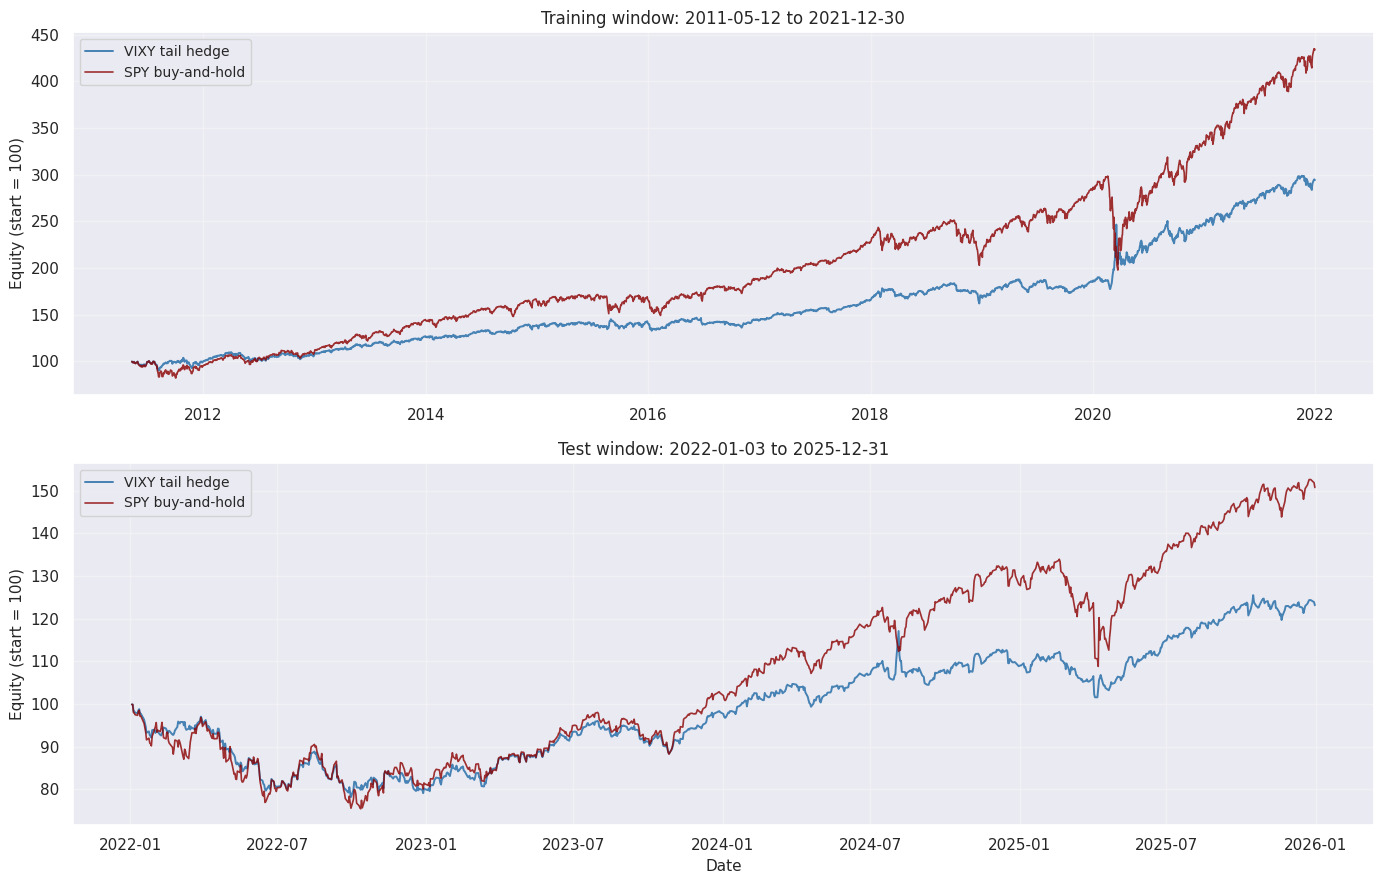

In [7]:
# Build a four-column comparison table: strategy and benchmark, on
# both the training and test windows. This puts the train-vs-test
# contrast directly next to the strategy-vs-benchmark contrast.
df_compare = pd.DataFrame({
    'Strategy (train)':  metrics_strategy_train,
    'SPY (train)':       metrics_bench_train,
    'Strategy (test)':   metrics_strategy_test,
    'SPY (test)':        metrics_bench_test,
})

print("Train vs test comparison:")
print()
print(df_compare.round(4))

# Plot the equity curves for both windows. Training window on top,
# test window on the bottom. Each panel shows the strategy and the
# SPY benchmark together so the relative performance is obvious.

# Build equity curves from the return streams, starting at 100.
def equity_curve(returns):
    return (1 + returns).cumprod() * 100

strategy_eq_train = equity_curve(strategy_returns_train)
bench_eq_train    = equity_curve(benchmark_returns_train)
strategy_eq_test  = equity_curve(strategy_returns_test)
bench_eq_test     = equity_curve(benchmark_returns_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Training window
axes[0].plot(strategy_eq_train.index, strategy_eq_train,
             color='steelblue', linewidth=1.4, label='VIXY tail hedge')
axes[0].plot(bench_eq_train.index, bench_eq_train,
             color='darkred', linewidth=1.2, label='SPY buy-and-hold',
             alpha=0.8)
axes[0].set_title(f'Training window: '
                  f'{strategy_eq_train.index.min().date()} to '
                  f'{strategy_eq_train.index.max().date()}',
                  fontsize=12)
axes[0].set_ylabel('Equity (start = 100)', fontsize=11)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Test window
axes[1].plot(strategy_eq_test.index, strategy_eq_test,
             color='steelblue', linewidth=1.4, label='VIXY tail hedge')
axes[1].plot(bench_eq_test.index, bench_eq_test,
             color='darkred', linewidth=1.2, label='SPY buy-and-hold',
             alpha=0.8)
axes[1].set_title(f'Test window: '
                  f'{strategy_eq_test.index.min().date()} to '
                  f'{strategy_eq_test.index.max().date()}',
                  fontsize=12)
axes[1].set_ylabel('Equity (start = 100)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The two panels make the contrast obvious. In the training window, the strategy tracked SPY closely through quiet periods and held up better through the 2015 China devaluation, the late 2018 growth scare, and the COVID drawdown of March 2020. SPY pulled away during the strong bull runs of 2019 and late 2020 to 2021, but the strategy delivered the smoother ride it was designed to deliver, which is what produced the better Sharpe and Calmar ratios in the training table.

The test window shows something different. Through the 2022 drawdown the strategy and SPY moved almost identically, both bottoming around 80 in late 2022. Through 2023 and 2024, SPY pulled away on the recovery while the strategy lagged. The April 2025 drawdown is visible on both lines but the strategy did not provide meaningful protection. Through the recovery into late 2025, SPY made new highs while the strategy ended around 124 against SPY's 152.

The pattern across both panels is consistent. The strategy lags during equity bull runs because it is structurally underweight equity by 20%. That lag is the price of protection. The strategy is supposed to earn that price back during volatility events that the hedge can capture. In the training window, the COVID episode plus the smaller 2015 and 2018 events were enough to do that on a risk-adjusted basis. In the test window, the volatility regime did not deliver the kind of event the hedge needed, so the structural drag from the 80% equity allocation dominated and the risk-adjusted metrics flipped in SPY's favor.

This is the regime ambiguity problem stated in pictures. The strategy underperformed on the test window. The numbers say so cleanly. But the underperformance is consistent with two very different stories: the strategy has no edge, or the test regime did not give the strategy what it needs to work. The next section walks through the three explanations and asks what we can and cannot conclude from this one OOS test.

## Section 7: Diagnostic Toolkit for an Ambiguous OOS Result

The test-window result is bad on the surface. Before we accept the verdict, we need to ask whether the underperformance reflects a strategy that does not work, a regime that did not give the strategy what it needs to work, or some combination of both. A single OOS test cannot answer that on its own evidence. It can be answered by building diagnostics that test each explanation separately.

This section walks through six diagnostics. Each one tests a different aspect of the result, and together they let us reach a verdict that the headline numbers cannot. Most of these techniques are general: they apply to any strategy whose OOS performance is ambiguous, not just to this one. Where a diagnostic is strategy-specific I will flag what stays the same across strategies and what has to be redesigned.

### 7.1 The Three Explanations

There are three explanations for a bad OOS result on a strategy with strong training-window performance.

The strategy has no real edge. The training-window outperformance was either luck or a product of parameters chosen with too much knowledge of what was in the training data. Under this explanation, the test result is the truth.

The strategy has a real edge but the test window did not give it the conditions it needs to work. The VIXY tail hedge is designed to add value during equity stress events. If the test window was a benign volatility regime, the strategy would lag SPY by roughly the cost of the hedge sleeve, which is what we see. Under this explanation, the test result is consistent with a working strategy that did not get many opportunities.

Both are partly true. The training-window numbers may have overstated the edge because the COVID event was unusually favorable, and the test-window numbers may have understated it because the regime was unusually benign. The truth is somewhere in the middle.

The chapter text discusses these explanations in more depth. What this notebook does is build the code-driven diagnostics that test each explanation against the data. We start with the regime question, because that is the explanation the chart from Section 6 already pointed toward.

### 7.2 Regime Characterization

The cleanest way to test explanation 2 is to characterize the volatility regime of each window directly. We compare the training and test windows on three dimensions: the percentage of trading days the hedge signal was on, the distribution of VIX levels, and the count of stress events at progressively higher VIX thresholds. If the test window had materially fewer signal-on days, lower VIX percentiles, and fewer stress events, the regime was different in the direction that hurts a tail-hedge strategy.

This diagnostic is general. Any strategy whose performance depends on a specific market regime can be evaluated this way: pick the regime variable the strategy responds to, characterize it on both windows, and look for material differences. What is strategy-specific here is that we are looking at the VIX. For a momentum strategy you would look at trend persistence; for a mean reversion strategy you would look at autocorrelation; for a pairs trade you would look at the spread distribution.

In [8]:
# Reconstruct the signal series so we can ask how often it was on in
# each window. We rebuild it inline rather than pulling it from the
# weights DataFrame because the weights have already collapsed signal
# information into allocations. The signal itself is the boolean we
# need.
vix = df_prices['^VIX']
vix_sma_90 = vix.rolling(window=90).mean()
spy_returns_full = df_prices['SPY'].pct_change()
spy_realized_vol = (spy_returns_full.rolling(window=10).std()
                    * np.sqrt(252) * 100)
signal_on = (spy_realized_vol > vix_sma_90)

# Slice the signal and the VIX into train and test using the same
# split logic we used everywhere else in the notebook.
signal_train = signal_on.loc[df_weights_train.index]
signal_test  = signal_on.loc[df_weights_test.index]
vix_train    = vix.loc[df_weights_train.index]
vix_test     = vix.loc[df_weights_test.index]

# Diagnostic 1: how often was the signal on?
pct_on_train = signal_train.mean() * 100
pct_on_test  = signal_test.mean() * 100

# Diagnostic 2: VIX distribution stats. We report mean, median, and
# the 75th, 90th, and 95th percentiles. The upper percentiles tell us
# how often the test window saw genuinely elevated volatility.
def vix_summary(series):
    return pd.Series({
        'mean':       series.mean(),
        'median':     series.median(),
        '75th pct':   series.quantile(0.75),
        '90th pct':   series.quantile(0.90),
        '95th pct':   series.quantile(0.95),
        'max':        series.max(),
    })

vix_stats = pd.DataFrame({
    'Train': vix_summary(vix_train),
    'Test':  vix_summary(vix_test),
})

# Diagnostic 3: stress event counts. How many trading days did VIX
# close above progressively higher thresholds? This separates the
# question "was VIX ever elevated" from the question "how often was
# VIX in genuine stress territory."
thresholds = [20, 25, 30, 35, 40]
stress_counts = pd.DataFrame({
    f'VIX > {t}': {
        'Train': int((vix_train > t).sum()),
        'Test':  int((vix_test > t).sum()),
    }
    for t in thresholds
}).T

# Normalize the stress counts to a per-year basis so the comparison
# is fair across windows of different length.
years_train = len(vix_train) / 252
years_test  = len(vix_test) / 252
stress_per_year = pd.DataFrame({
    f'VIX > {t}': {
        'Train (days/yr)': (vix_train > t).sum() / years_train,
        'Test (days/yr)':  (vix_test  > t).sum() / years_test,
    }
    for t in thresholds
}).T

print(f"Signal-on percentage of trading days:")
print(f"  Train: {pct_on_train:.1f}%")
print(f"  Test:  {pct_on_test:.1f}%")
print()
print("VIX distribution:")
print(vix_stats.round(2))
print()
print("Stress events (raw count of trading days):")
print(stress_counts)

Signal-on percentage of trading days:
  Train: 20.1%
  Test:  21.4%

VIX distribution:
          Train   Test
mean      17.72  19.26
median    15.69  17.83
75th pct  19.73  22.27
90th pct  26.20  27.53
95th pct  31.97  30.49
max       82.69  52.33

Stress events (raw count of trading days):
          Train  Test
VIX > 20    644   357
VIX > 25    317   157
VIX > 30    170    61
VIX > 35     85     8
VIX > 40     47     4


The numbers here complicate the regime-was-hostile story rather than confirm it.

The signal-on percentage was almost identical across windows: 20.1% in training and 21.4% in test. The hedge was active just as often on a per-day basis. Whatever else was different about the test window, the strategy was not under-utilized.

The VIX distributions look similar through the median and the 75th percentile. The test window actually had a slightly higher mean (19.26 vs 17.72) and a slightly higher median (17.83 vs 15.69). At the 90th percentile the two windows are within a hair of each other. So the test window was not dominated by unusually low volatility.

The divergence shows up in the upper tail. The 95th percentile is roughly equal. The maximum is materially different (52.33 in test vs 82.69 in train). The stress-event counts are where the windows really separate: at VIX > 30 the test window had less than half the stress days per year as the training window, and at VIX > 35 and VIX > 40 the test window had almost none (8 and 4 raw days). The training window had 85 days above 35 and 47 days above 40, almost all of them concentrated in the COVID period.

Putting this together: the test window had similar baseline volatility, similar moderate-stress frequency, and almost no extreme stress. The COVID event in the training window was a 30-day stretch where VIX traded in the 50s, 60s, and 70s; the test window had nothing comparable. The April 2025 spike to 52 was the closest thing, and it was brief.

This means the regime explanation has to be more careful. The test window did give the strategy plenty of moderate-stress opportunities. What it did not give the strategy was a true tail event. If the strategy gets most of its risk-adjusted advantage from extreme stress, the absence of extreme stress would explain a lot of the underperformance. If the strategy is supposed to add value at moderate stress (VIX in the 20s and low 30s), the absence of extreme stress is a weaker excuse.

The diagnostics in 7.3 and 7.4 will help separate these two cases. The hedge contribution analysis tells us whether the defensive sleeve added value at all on the test window. The conditional performance analysis tells us whether the strategy added value on the days the signal was on, regardless of how extreme the stress was on those days.

In [9]:
# Duration of stress events: how long does VIX stay above each
# threshold once it crosses? We measure this as the lengths of
# consecutive runs of trading days where VIX exceeds the threshold.
#
# A single-day spike and a two-week stretch both count once in the
# raw stress-day count, but they have very different implications
# for a tail-hedge strategy. VIXY positions need sustained elevation
# to add value; brief spikes revert before the position can do its
# job. Duration is the diagnostic that separates these cases.

def stress_run_lengths(vix_series, threshold):
    """
    Return the lengths of consecutive runs where VIX > threshold.
    Each run is a stretch of trading days during which VIX stayed
    above the threshold without dropping below.
    """
    above = (vix_series > threshold).astype(int)
    # Mark the start of each run with a 1 by diffing the boolean.
    # Cumulatively sum these markers to assign a unique run ID to
    # each consecutive stretch of above-threshold days. Runs of
    # below-threshold days get filtered out by the .where().
    run_id = (above.diff() == 1).cumsum()
    runs = above.groupby(run_id).sum()
    # Keep only the runs that are actually above-threshold runs (sum > 0)
    return runs[runs > 0].values

# For each threshold, compute the count, mean length, max length,
# and total days for the train and test windows.
duration_rows = []
for t in thresholds:
    train_runs = stress_run_lengths(vix_train, t)
    test_runs  = stress_run_lengths(vix_test,  t)
    duration_rows.append({
        'Threshold':       f'VIX > {t}',
        'Train runs':      len(train_runs),
        'Train mean':      train_runs.mean() if len(train_runs) else 0,
        'Train max':       train_runs.max()  if len(train_runs) else 0,
        'Test runs':       len(test_runs),
        'Test mean':       test_runs.mean()  if len(test_runs) else 0,
        'Test max':        test_runs.max()   if len(test_runs) else 0,
    })

df_durations = pd.DataFrame(duration_rows).set_index('Threshold')

print("Stress event duration (consecutive trading days above threshold):")
print()
print(df_durations.round(1))

Stress event duration (consecutive trading days above threshold):

           Train runs  Train mean  Train max  Test runs  Test mean  Test max
Threshold                                                                   
VIX > 20           75         8.6        246         35       10.2        87
VIX > 25           36         8.8         72         21        7.5        38
VIX > 30           21         8.1         50         14        4.4        11
VIX > 35           18         4.7         36          4        2.0         3
VIX > 40           13         3.6         26          2        2.0         3


Duration tells the story the count and distribution alone could not.

At low and moderate stress, the two windows look more alike than the count suggested. Above VIX 20, both windows had similar mean run lengths (8.6 vs 10.2 days) and the test window had a longer mean stretch than training. Above VIX 25, the mean run lengths are nearly equal. The test window did get sustained moderate stress.

The picture changes sharply above VIX 30. The training window had 21 runs at this level with a mean length of 8.1 days and a maximum of 50. The test window had 14 runs but the mean dropped to 4.4 days and the maximum was only 11. Above VIX 35, the training window had 18 runs averaging 4.7 days with a maximum of 36 (the COVID stretch). The test window had 4 runs averaging 2.0 days with a maximum of 3. Above VIX 40, the training window had 13 runs averaging 3.6 days with a maximum of 26. The test window had 2 runs averaging 2.0 days with a maximum of 3.

What this says, plainly: the test window had moderate stress similar to the training window, but it had nothing like the COVID-era sustained tail stress. The 50-day stretch above VIX 30 in training is the kind of event a tail hedge is built for. The longest comparable test-window run was 11 days. The 36-day stretch above VIX 35 in training has no analog at all in test.

This sharpens the verdict from the count diagnostic. The test window was not a low-volatility regime in the simple sense. It was a regime with normal moderate stress but no sustained tail event. A tail-hedge strategy should be able to add value on moderate stress; that is most of its working surface. It does not get to use the absence of tail events as a complete excuse. Whether the moderate-stress days actually paid is what 7.3 and 7.4 will tell us.

### 7.3 Hedge Contribution Analysis

The strategy holds a constant 80% SPY allocation. The remaining 20% sits in BIL by default and shifts into VIXY when the signal fires. Most of the strategy's day-to-day return comes from the 80% SPY allocation, which has nothing to do with the signal logic. The part the signal actually controls is the BIL/VIXY shift inside the defensive sleeve.

To isolate what the signal contributed, we compare the strategy to a passive 80/20 SPY/BIL baseline on each window. The baseline holds the same equity exposure as the strategy but never moves into VIXY. Whatever the strategy delivered above or below the 80/20 baseline is the signal's contribution. We compute this on three windows: training with COVID, training excluding February 1 through April 30 2020, and test. If the signal's contribution collapses or goes negative once COVID is removed, the strategy was a one-event strategy and the training-window risk-adjusted advantage was carried by a single episode. If the contribution holds up reasonably well, the strategy has broader content and the test-window underperformance is more likely a regime issue.

This diagnostic is general. Any strategy with a default allocation plus a conditional overlay can be evaluated this way: backtest the default allocation alone, backtest the strategy, and compare. The choice of baseline is the strategy-specific design call. For a moving average crossover the baseline would be 100% buy-and-hold of the underlying. For a mean-reversion overlay it would be the underlying itself or a static target weight. The analytical machinery is identical.

In [10]:
# Define the COVID exclusion window. Wider than the peak-to-trough
# drawdown so we capture the full elevated-VIX period where the
# strategy was actively hedging.
covid_start = '2020-02-01'
covid_end   = '2020-04-30'

# Build the static 80/20 SPY/BIL baseline weights. SPY at the same
# 80% as the strategy, BIL at 20%, no VIXY ever, no signal logic.
# The baseline lets us measure what an investor would have earned
# from the equity sleeve alone, without the signal-driven overlay.
def build_baseline_weights(price_index):
    """
    Construct sparse baseline weights for an 80/20 SPY/BIL portfolio
    on the given date index. One rebalance on day one, held forever.
    """
    df_b = pd.DataFrame(np.nan, index=price_index, columns=['SPY', 'BIL'])
    df_b.iloc[0] = [0.80, 0.20]
    return df_b

# Run the 80/20 baseline backtest on a given price slice. Same fees,
# slippage, and engine settings as the strategy backtest so the two
# return streams are directly comparable.
def run_baseline_backtest(df_prices_slice):
    weights = build_baseline_weights(df_prices_slice.index)
    pf = vbt.Portfolio.from_orders(
        close        = df_prices_slice[['SPY', 'BIL']],
        size         = weights,
        size_type    = 'targetpercent',
        group_by     = True,
        cash_sharing = True,
        call_seq     = 'auto',
        fees         = fees,
        slippage     = slippage,
        freq         = '1D'
    )
    return pf.returns()

# Run the baseline on training and test windows.
baseline_returns_train = run_baseline_backtest(df_prices_train)
baseline_returns_test  = run_baseline_backtest(df_prices_test)

# Build the COVID-excluded training slice. We mask out the COVID
# window from both the strategy and the baseline return streams,
# then compute metrics on the remaining days. Excluding rather than
# rerunning the backtest is the right approach here because we are
# asking how the strategy would have looked if COVID had not occurred,
# not how the strategy would have traded on a counterfactual history.
covid_mask_train = (
    (strategy_returns_train.index >= covid_start) &
    (strategy_returns_train.index <= covid_end)
)
strategy_returns_train_xcovid = strategy_returns_train[~covid_mask_train]
baseline_returns_train_xcovid = baseline_returns_train[~covid_mask_train]

# Compute the signal contribution on each window: the daily
# difference between the strategy and the 80/20 baseline. This is
# what the BIL/VIXY shift added or subtracted on a given day.
signal_contrib_train         = strategy_returns_train         - baseline_returns_train
signal_contrib_train_xcovid  = strategy_returns_train_xcovid  - baseline_returns_train_xcovid
signal_contrib_test          = strategy_returns_test          - baseline_returns_test

# Build a comparison table. For each window we report the strategy
# CAGR, the 80/20 baseline CAGR, the difference (signal contribution
# in CAGR terms), the signal contribution Sharpe, and the strategy's
# Sharpe minus the baseline's Sharpe (the risk-adjusted advantage).
def summarize_contribution(strat_rets, base_rets, contrib_rets, label):
    strat_metrics = calculate_performance_metrics(strat_rets)
    base_metrics  = calculate_performance_metrics(base_rets)

    # Strip percent signs and convert to floats for arithmetic.
    def num(x):
        if isinstance(x, str):
            return float(x.replace('%', ''))
        return float(x)

    strat_cagr  = num(strat_metrics['Ann. Return (CAGR)'])
    base_cagr   = num(base_metrics['Ann. Return (CAGR)'])
    strat_shrp  = num(strat_metrics['Sharpe Ratio'])
    base_shrp   = num(base_metrics['Sharpe Ratio'])

    # Signal contribution as a return series, annualized properly.
    contrib_cagr = (1 + contrib_rets).prod() ** (252 / len(contrib_rets)) - 1
    contrib_vol  = contrib_rets.std() * np.sqrt(252)
    contrib_shrp = (contrib_rets.mean() * 252) / contrib_vol if contrib_vol > 0 else 0.0

    return pd.Series({
        'Strategy CAGR':           f"{strat_cagr:.2f}%",
        '80/20 baseline CAGR':     f"{base_cagr:.2f}%",
        'Strategy − baseline':     f"{strat_cagr - base_cagr:+.2f}%",
        'Signal contrib CAGR':     f"{contrib_cagr * 100:+.2f}%",
        'Signal contrib Sharpe':   f"{contrib_shrp:.3f}",
        'Strategy Sharpe':         f"{strat_shrp:.3f}",
        '80/20 Sharpe':            f"{base_shrp:.3f}",
        'Strategy − baseline Sharpe': f"{strat_shrp - base_shrp:+.3f}",
    }, name=label)

df_contribution = pd.concat([
    summarize_contribution(strategy_returns_train,
                           baseline_returns_train,
                           signal_contrib_train,
                           'Train (full)'),
    summarize_contribution(strategy_returns_train_xcovid,
                           baseline_returns_train_xcovid,
                           signal_contrib_train_xcovid,
                           'Train (ex-COVID)'),
    summarize_contribution(strategy_returns_test,
                           baseline_returns_test,
                           signal_contrib_test,
                           'Test'),
], axis=1)

print("Hedge contribution analysis: strategy vs 80/20 SPY/BIL baseline")
print()
print(df_contribution)

Hedge contribution analysis: strategy vs 80/20 SPY/BIL baseline

                           Train (full) Train (ex-COVID)    Test
Strategy CAGR                    10.68%            9.60%   5.37%
80/20 baseline CAGR              13.03%           14.32%   9.57%
Strategy − baseline              -2.35%           -4.72%  -4.20%
Signal contrib CAGR              -3.37%           -4.68%  -4.51%
Signal contrib Sharpe            -0.184           -0.590  -0.404
Strategy Sharpe                   0.915            0.956   0.420
80/20 Sharpe                      0.879            1.139   0.674
Strategy − baseline Sharpe       +0.036           -0.183  -0.254


The numbers tell a clear story once we read them in the right frame.

The Strategy − baseline Sharpe row is the cleanest summary. With COVID in the training window, the strategy beat the 80/20 baseline on a risk-adjusted basis by 0.036 Sharpe. Take COVID out, and the strategy underperformed the 80/20 baseline by 0.183 Sharpe. The signal contribution Sharpe went from -0.184 to -0.590. Read literally, the signal cost more than it added on training when the one big tail event was excluded, and the picture on the test window (-0.404 signal contribution Sharpe, -0.254 strategy-minus-baseline Sharpe) looks more like the ex-COVID training number than the full training number.

What is clear: the COVID event carried the training-window risk-adjusted advantage. Strip it out and the signal is a drag during normal markets.

This needs to be framed correctly, because the casual read ("the strategy does not work") misses what the strategy is actually for. The VIXY tail hedge is insurance. It is designed to pay during COVID-scale events and to cost something during normal markets. The cost is the structural drag from holding 20% defensive plus the small cost of running a hedge that fires on moderate stress without a true tail event to capture. The training window contained one claim event and many years of premium payments, and the net was a small risk-adjusted advantage. The training-ex-COVID and test windows show what years of premium payments look like without a claim. They are losing periods by design.

This is the correct way to evaluate a tail hedge. You do not judge insurance by its return in years without a fire. You judge it by whether it pays when the fire happens, and whether the cost of running it through quiet years is acceptable in exchange for the protection. The 7.3 numbers tell us the cost-of-running-it side: roughly 4.2 to 4.7 percentage points of CAGR drag versus the 80/20 baseline during normal regimes. The COVID training data tells us the protection side: -17.45% drawdown vs -33.72% on the 80/20 baseline (which we computed earlier in Section 5).

What 7.3 does not let us conclude is whether this is a good trade. That depends on the investor's drawdown tolerance, time horizon, and views on tail event frequency. What 7.3 does let us conclude is that the test window's underperformance is consistent with a working insurance product on a no-claim period, and the training-window outperformance was carried by the one claim event.

The bootstrap diagnostic in 7.4 will sharpen this further. The test for whether the strategy adds value above the 80/20 baseline is statistical: given the regime the data describes, can we reject the null that the strategy and the baseline are drawn from the same risk-adjusted distribution?

### 7.4 Block Bootstrap on the Return Streams

The 7.3 hedge contribution analysis gave us point estimates: the strategy underperformed the 80/20 baseline by 0.183 Sharpe on the ex-COVID training window and 0.254 Sharpe on the test window. Those are point estimates with sampling noise around them. Without a confidence interval, we cannot tell whether the negative Sharpe difference is statistically distinguishable from zero or whether it sits within the noise band of any 11-year sample drawn from the same regime.

The block bootstrap puts a confidence interval on those point estimates. We resample the actual daily return pairs (strategy and 80/20 baseline) jointly, in blocks of consecutive days to preserve the within-block correlation between the two return streams. We do this many times and observe the empirical distribution of the metrics we care about. The 2.5th and 97.5th percentiles of the bootstrapped Sharpe difference define a 95% confidence interval. If that interval crosses zero, the data does not let us reject the hypothesis that the strategy and the baseline have the same Sharpe.

We use the moving block bootstrap. Block size matters: too short and we destroy the volatility clustering and short-term autocorrelation that make daily equity returns non-IID, too long and we have too few independent blocks per draw. The conventional default is 20 trading days (roughly one month). We run block sizes 20 and 40 side by side so the sensitivity is visible.

This is a general diagnostic. Any backtested strategy with a return stream and a baseline can be evaluated this way. The block size is the strategy-specific (or really data-specific) design choice. For higher-frequency data, blocks would be larger in trading-day terms. For monthly data, blocks of 3 to 6 months are standard. The mechanics of resampling and metric computation do not change.

We run the bootstrap on the full training window only. The test window is too short for a stable bootstrap with these block sizes. The training window is also where the meaningful hedge contribution result lives.

Block bootstrap on training-window returns
  Sample size: 2,678 trading days
  Bootstrap draws: 1000
  Random seed: 42

            Actual strategy Sharpe  Actual baseline Sharpe  Actual difference  \
Block size                                                                      
20                           0.928                  0.9008             0.0272   
40                           0.928                  0.9008             0.0272   

            Bootstrap mean difference  Difference 2.5th pct  \
Block size                                                    
20                             0.0047               -0.6025   
40                             0.0296               -0.5056   

            Difference 97.5th pct  P(strategy > baseline)  
Block size                                                 
20                         0.7019                   0.486  
40                         0.5871                   0.532  


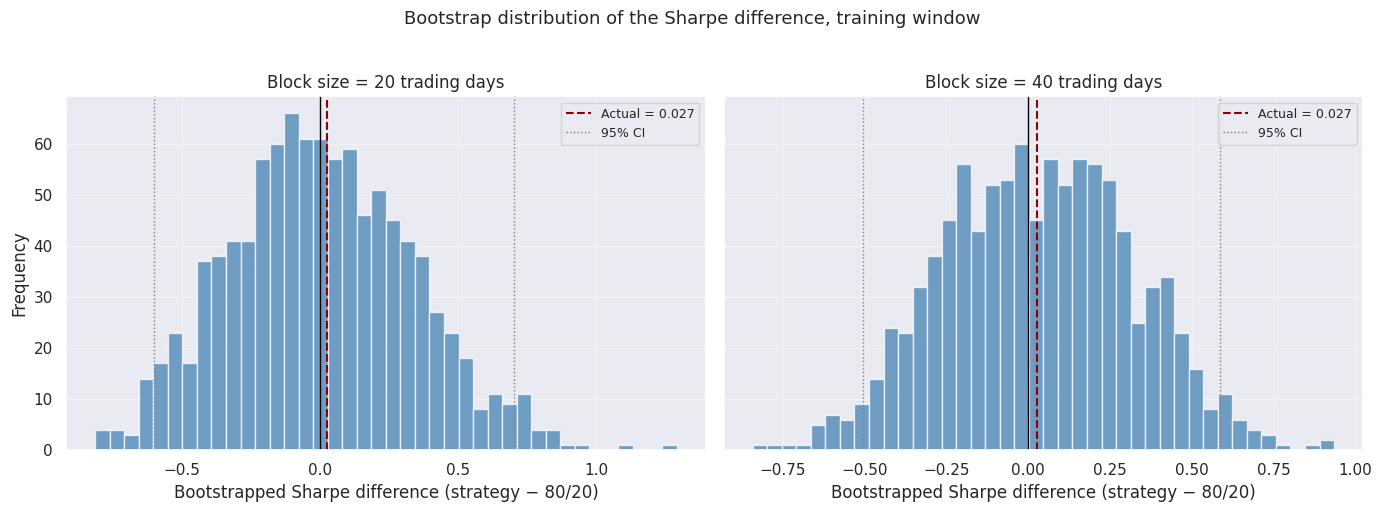

In [11]:
# Set a random seed for reproducibility. Anyone running this notebook
# will get the same numbers we discuss in the markdown that follows.
# If you want to see how stable the bootstrap is across seeds, change
# this number and rerun.
np.random.seed(42)

# Number of bootstrap draws. 1,000 is the standard for empirical
# confidence intervals on a Sharpe ratio.
n_draws = 1000

# Block sizes to compare. 20 trading days is the standard default for
# daily equity data. 40 is a sensitivity check.
block_sizes = [20, 40]

# Build a joint DataFrame of strategy and baseline returns aligned on
# date. Resampling them as pairs preserves the contemporaneous
# correlation, which is what makes the Sharpe difference well-defined
# on each draw.
df_returns_train = pd.DataFrame({
    'strategy': strategy_returns_train,
    'baseline': baseline_returns_train,
}).dropna()

n_obs = len(df_returns_train)


def moving_block_bootstrap(df, block_size, target_length, rng):
    """
    Draw a single moving block bootstrap sample of approximately
    target_length rows from df.

    The moving block bootstrap selects starting indices uniformly from
    the range [0, len(df) - block_size], then takes block_size
    consecutive rows starting at each chosen index. We concatenate
    blocks until we have at least target_length rows, then trim.
    """
    max_start = len(df) - block_size
    n_blocks_needed = int(np.ceil(target_length / block_size))
    starts = rng.integers(low=0, high=max_start + 1, size=n_blocks_needed)
    blocks = [df.iloc[s:s + block_size].values for s in starts]
    sample = np.concatenate(blocks, axis=0)[:target_length]
    return sample


def annualized_sharpe(returns):
    """
    Annualized Sharpe ratio assuming daily data. Returns 0 if the
    return series has zero variance, which avoids division by zero
    on degenerate bootstrap draws.
    """
    s = returns.std()
    if s == 0:
        return 0.0
    return (returns.mean() / s) * np.sqrt(252)


# Run the bootstrap for each block size. We collect the strategy
# Sharpe, the baseline Sharpe, and the difference on each draw.
results = {}
rng = np.random.default_rng(42)

for L in block_sizes:
    sharpes_strat = np.empty(n_draws)
    sharpes_base  = np.empty(n_draws)
    sharpes_diff  = np.empty(n_draws)

    for i in range(n_draws):
        sample = moving_block_bootstrap(df_returns_train,
                                        block_size=L,
                                        target_length=n_obs,
                                        rng=rng)
        strat_rets = sample[:, 0]
        base_rets  = sample[:, 1]

        sharpes_strat[i] = annualized_sharpe(strat_rets)
        sharpes_base[i]  = annualized_sharpe(base_rets)
        sharpes_diff[i]  = sharpes_strat[i] - sharpes_base[i]

    results[L] = {
        'strategy': sharpes_strat,
        'baseline': sharpes_base,
        'difference': sharpes_diff,
    }


# Summarize. For each block size, report the actual point estimate
# (computed on the full unsampled data), the bootstrap mean, the 2.5th
# and 97.5th percentiles (95% confidence interval), and the fraction
# of draws where the strategy beat the baseline (one-sided p-value
# proxy for the null that they have the same Sharpe).
def actual_sharpe(rets):
    return annualized_sharpe(rets.values)

actual_strat = actual_sharpe(df_returns_train['strategy'])
actual_base  = actual_sharpe(df_returns_train['baseline'])
actual_diff  = actual_strat - actual_base

summary_rows = []
for L in block_sizes:
    diff = results[L]['difference']
    summary_rows.append({
        'Block size':                       L,
        'Actual strategy Sharpe':           actual_strat,
        'Actual baseline Sharpe':           actual_base,
        'Actual difference':                actual_diff,
        'Bootstrap mean difference':        diff.mean(),
        'Difference 2.5th pct':             np.percentile(diff, 2.5),
        'Difference 97.5th pct':            np.percentile(diff, 97.5),
        'P(strategy > baseline)':           (diff > 0).mean(),
    })

df_bootstrap_summary = pd.DataFrame(summary_rows).set_index('Block size')

print("Block bootstrap on training-window returns")
print(f"  Sample size: {n_obs:,} trading days")
print(f"  Bootstrap draws: {n_draws}")
print(f"  Random seed: 42")
print()
print(df_bootstrap_summary.round(4))


# Plot the bootstrap distributions of the Sharpe difference for both
# block sizes, with the actual point estimate marked. The visualization
# makes the confidence interval intuitive in a way the table cannot.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, L in zip(axes, block_sizes):
    diff = results[L]['difference']
    ax.hist(diff, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.0, linestyle='-')
    ax.axvline(actual_diff, color='darkred', linewidth=1.5,
               linestyle='--', label=f'Actual = {actual_diff:.3f}')
    ax.axvline(np.percentile(diff, 2.5), color='gray',
               linewidth=1.0, linestyle=':')
    ax.axvline(np.percentile(diff, 97.5), color='gray',
               linewidth=1.0, linestyle=':',
               label='95% CI')
    ax.set_title(f'Block size = {L} trading days', fontsize=12)
    ax.set_xlabel('Bootstrapped Sharpe difference (strategy − 80/20)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Frequency')
plt.suptitle('Bootstrap distribution of the Sharpe difference, training window',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

This is the diagnostic that should make us most cautious about the training-window verdict.

The actual Sharpe difference between the strategy and the 80/20 baseline on the full training window is +0.027. The point estimate says the strategy beat the baseline. But the bootstrap distribution is wide. With 20-day blocks, the 95% confidence interval runs from -0.60 to +0.70. With 40-day blocks, it runs from -0.51 to +0.59. Both intervals straddle zero by a wide margin. Both probabilities of strategy-greater-than-baseline are essentially coin flips: 0.486 with 20-day blocks, 0.532 with 40-day blocks.

The block size sensitivity is mild. The 20-day distribution has slightly fatter tails than the 40-day distribution, which is what we expect (longer blocks preserve more of the autocorrelation structure but produce fewer independent draws per sample). The bootstrap mean is close to zero in both cases. Both block sizes deliver the same verdict.

Read directly: we cannot reject the null that the strategy and the 80/20 baseline have the same Sharpe ratio over this regime. The training-window outperformance of +0.027 Sharpe is well within the noise band of any 11-year sample drawn from this regime. We saw in 7.3 that this small advantage was carried by COVID; we now see in 7.4 that even with COVID in, the advantage is not statistically distinguishable from zero.

This is not a verdict that the strategy is broken. It is a verdict that the training data does not contain enough evidence to claim the strategy adds risk-adjusted value. That is a different and much more limited claim than what the headline training-window numbers suggested.

This connects directly to the false discovery problem from Notebook 7.3. The eye-catching Sharpe of 0.93 in the training window looked meaningful in isolation. The bootstrap reveals that an 11-year sample from this regime can produce strategy-baseline Sharpe differences anywhere from -0.6 to +0.7 just from sampling variation. A point estimate of +0.027 inside that band is not evidence of an edge. It is evidence that the metric we computed has a wide confidence interval, and zero is well inside it.

What this means for the broader question: the training window does not establish that the strategy works. The test window does not establish that it fails. Both are point estimates inside wide noise bands. The walk-forward analysis in Notebook 9.2 is the response to this: instead of trying to extract signal from one window or two, we look for the strategy's behavior across many windows and ask whether a pattern emerges that survives the noise.

We continue with the diagnostic toolkit because it tells us things the bootstrap cannot: not whether the headline metric is statistically distinguishable from zero, but whether the strategy is doing what it is supposed to do when it is supposed to do it. The next diagnostic, Approach B, asks the robustness question: how would the strategy have looked on plausible alternative histories drawn from the same regime?

### 7.5 Block Bootstrap with Full Backtest Re-run (Approach B)

Section 7.4 asked whether the strategy's training-window Sharpe difference is statistically distinguishable from zero given the actual return stream. This section asks a different question: how would the strategy have performed on plausible alternative histories drawn from the same regime?

The mechanic: we resample blocks of joint daily asset returns, synthesize fresh price series from the bootstrapped returns, rebuild the signal on the synthetic data, run a full VectorBT backtest on each draw, and record the resulting Sharpe. After many draws we have empirical distributions of how the strategy and the 80/20 baseline would have performed across alternative orderings of regime blocks.

Two implementation choices worth flagging. First, VIXY synthesis. We follow the Notebook 8.2 pattern: synthesize from adjusted-close returns, fresh price series starting at 1.0 on each draw. Second, signal warmup. We draw an extra 90 trading days per sample to warm up the moving average, then trim those days before computing metrics.

We use 500 draws here instead of 7.4's 1,000 because each draw runs a full backtest. Same seed and block sizes as 7.4 for direct comparison.

One caveat. The bootstrap can only resample what is in the source. Our source data starts in 2011 and does not include the 2008 financial crisis. Synthetic histories can rearrange the post-2011 regime composition; they cannot create stress events the source never contained.

Running Approach B bootstrap with block size = 20 ...
  Done.
Running Approach B bootstrap with block size = 40 ...
  Done.

Approach B: block bootstrap with full backtest re-run
  Sample size per draw: 2,677 trading days plus 90 warmup
  Bootstrap draws: 500
  Random seed: 42

            Bootstrap mean strat Sharpe  Bootstrap mean base Sharpe  \
Block size                                                            
20                               0.9561                      0.9371   
40                               0.9884                      0.9661   

            Bootstrap mean diff  Diff 2.5th pct  Diff 97.5th pct  \
Block size                                                         
20                       0.0191         -0.1251           0.2593   
40                       0.0223         -0.1342           0.3194   

            P(strat > baseline)  
Block size                       
20                        0.558  
40                        0.602  


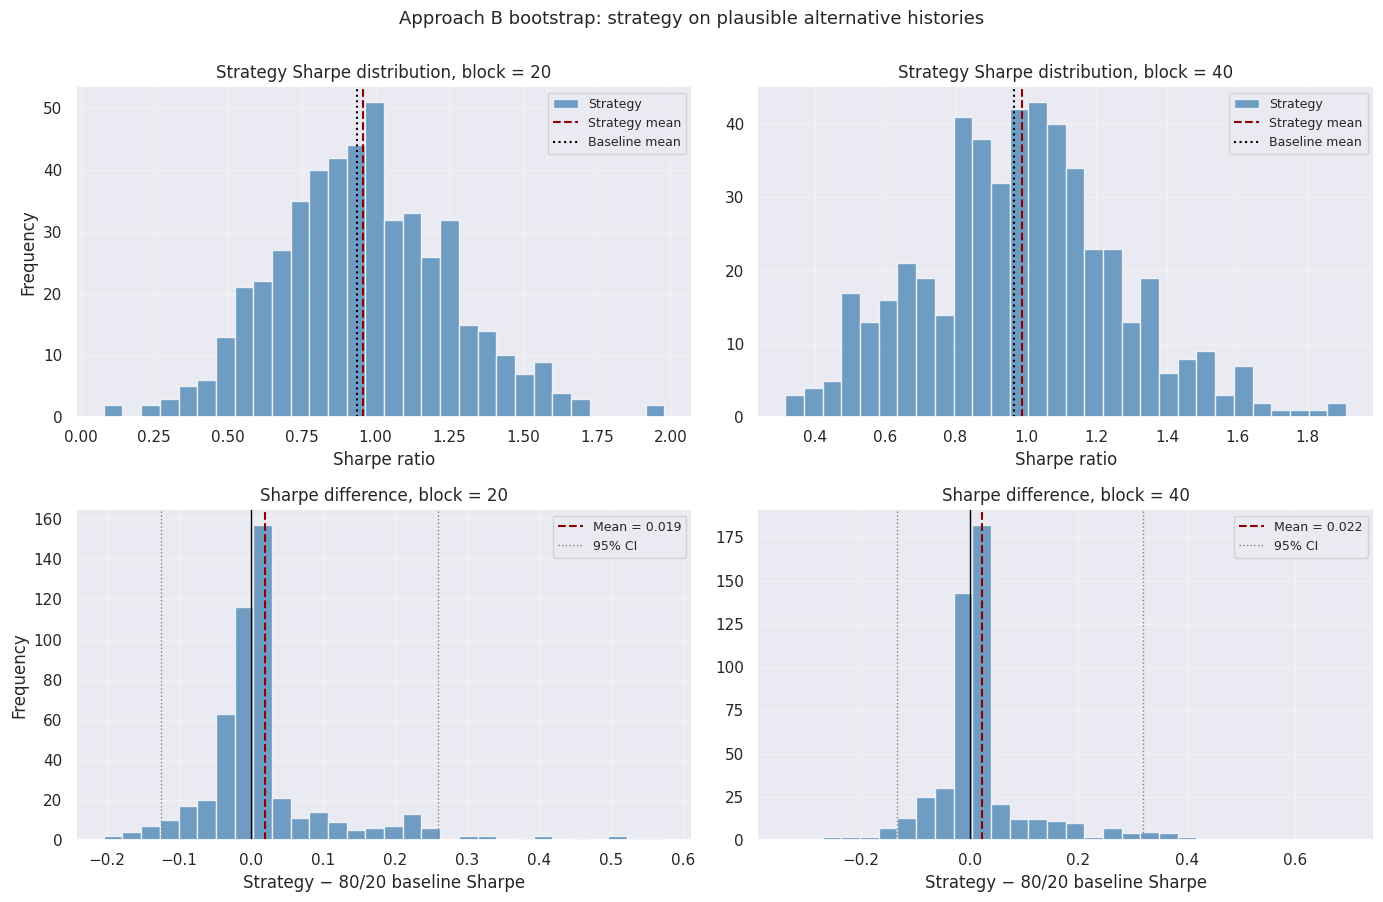

In [12]:
# Approach B: bootstrap the asset returns, synthesize prices, rerun
# the full backtest. We follow the Notebook 8.2 pattern for VIXY
# synthesis: adjusted-close returns, fresh price series starting at
# 1.0 on each draw, all assets synthesized the same way.

# Compute training-window asset returns from adjusted close prices.
# These are the joint returns we will resample in blocks.
df_returns_assets_train = df_prices_train.pct_change().dropna()

# Add ^VIX returns to the same DataFrame so the signal-related state
# (VIX level, the 90-day MA, realized vol) can be reconstructed on
# bootstrapped data. ^VIX is an index, not a tradeable, but we need
# its return series to rebuild the signal on synthetic histories.
df_returns_assets_train['^VIX'] = (
    df_prices['^VIX'].loc[df_prices_train.index].pct_change()
)
df_returns_assets_train = df_returns_assets_train.dropna()

# Bootstrap configuration. 500 draws is a compromise between
# precision and runtime; the full backtest per draw is the slow step.
n_draws_b = 500
warmup_days = 90
target_length_b = len(df_returns_assets_train)


def synthesize_prices_from_returns(returns_array, columns, start_date):
    """
    Build a synthetic price DataFrame from a returns array.

    Each column starts at 1.0 on day one and compounds forward. The
    date index starts at start_date and runs for as many trading days
    as the returns array has.
    """
    n = returns_array.shape[0]
    dates = pd.bdate_range(start=start_date, periods=n + 1)
    # Prepend a row of zeros so the cumulative product produces n+1
    # price points with day-one price of 1.0.
    rets_with_seed = np.vstack([np.zeros((1, returns_array.shape[1])),
                                returns_array])
    prices = (1.0 + rets_with_seed).cumprod(axis=0)
    return pd.DataFrame(prices, index=dates, columns=columns)


def run_one_bootstrap_draw(returns_df, block_size, target_length,
                           warmup_days, rng):
    """
    Execute one bootstrap draw end to end:
      1. Resample blocks of joint asset returns to length
         target_length + warmup_days.
      2. Synthesize prices from the bootstrapped returns.
      3. Rebuild the signal and weights on the synthetic data.
      4. Run the strategy and the 80/20 baseline backtests.
      5. Return Sharpe ratios for both.

    Returns (strategy_sharpe, baseline_sharpe, strategy_cagr,
    baseline_cagr) on the post-warmup portion of the synthetic history.
    """
    # Resample blocks. We need warmup_days extra so the 90-day MA
    # warms up before the strategy starts trading on the draw.
    full_length = target_length + warmup_days
    sample_arr = moving_block_bootstrap(
        returns_df,
        block_size=block_size,
        target_length=full_length,
        rng=rng
    )

    # Synthesize prices on the full draw including warmup.
    df_synth = synthesize_prices_from_returns(
        sample_arr,
        columns=returns_df.columns.tolist(),
        start_date='2000-01-01'   # arbitrary; only the index spacing matters
    )

    # Rebuild the signal on the synthetic data using the canonical
    # function. We reuse the same calculate_vixy_weights logic, which
    # internally trims the warmup.
    df_synth_strategy = calculate_vixy_weights(df_synth)

    # The synthetic dates after the warmup is what we backtest on.
    df_synth_post = df_synth_strategy
    df_prices_post = df_synth.loc[df_synth_post.index, ['SPY', 'BIL', 'VIXY']]

    # Sparse weights for the strategy backtest.
    sparse_strategy = to_sparse_weights(df_synth_post)

    # Strategy backtest.
    pf_s = vbt.Portfolio.from_orders(
        close=df_prices_post,
        size=sparse_strategy,
        size_type='targetpercent',
        group_by=True,
        cash_sharing=True,
        call_seq='auto',
        fees=fees,
        slippage=slippage,
        freq='1D'
    )
    s_rets = pf_s.returns()

    # 80/20 baseline backtest on the same synthetic prices.
    df_baseline = build_baseline_weights(df_prices_post.index)
    pf_b = vbt.Portfolio.from_orders(
        close=df_prices_post[['SPY', 'BIL']],
        size=df_baseline,
        size_type='targetpercent',
        group_by=True,
        cash_sharing=True,
        call_seq='auto',
        fees=fees,
        slippage=slippage,
        freq='1D'
    )
    b_rets = pf_b.returns()

    # Annualized metrics for both. CAGR computed from total return
    # over the synthetic period; Sharpe annualized at sqrt(252).
    def cagr(rets):
        n = len(rets)
        if n == 0:
            return 0.0
        return (1 + rets).prod() ** (252 / n) - 1

    return (annualized_sharpe(s_rets.values),
            annualized_sharpe(b_rets.values),
            cagr(s_rets),
            cagr(b_rets))


# Run the bootstrap for each block size. This loop is the slow part
# of the notebook; expect 30-90 seconds per block size on Colab.
results_b = {}
rng_b = np.random.default_rng(42)

for L in block_sizes:
    print(f"Running Approach B bootstrap with block size = {L} ...")
    s_sharpes = np.empty(n_draws_b)
    b_sharpes = np.empty(n_draws_b)
    s_cagrs   = np.empty(n_draws_b)
    b_cagrs   = np.empty(n_draws_b)

    for i in range(n_draws_b):
        s_shrp, b_shrp, s_cgr, b_cgr = run_one_bootstrap_draw(
            df_returns_assets_train,
            block_size=L,
            target_length=target_length_b,
            warmup_days=warmup_days,
            rng=rng_b
        )
        s_sharpes[i] = s_shrp
        b_sharpes[i] = b_shrp
        s_cagrs[i]   = s_cgr
        b_cagrs[i]   = b_cgr

    results_b[L] = {
        'strategy_sharpe': s_sharpes,
        'baseline_sharpe': b_sharpes,
        'strategy_cagr':   s_cagrs,
        'baseline_cagr':   b_cagrs,
        'sharpe_diff':     s_sharpes - b_sharpes,
    }
    print(f"  Done.")

# Summarize.
summary_b_rows = []
for L in block_sizes:
    diff = results_b[L]['sharpe_diff']
    summary_b_rows.append({
        'Block size':                  L,
        'Bootstrap mean strat Sharpe': results_b[L]['strategy_sharpe'].mean(),
        'Bootstrap mean base Sharpe':  results_b[L]['baseline_sharpe'].mean(),
        'Bootstrap mean diff':         diff.mean(),
        'Diff 2.5th pct':              np.percentile(diff, 2.5),
        'Diff 97.5th pct':             np.percentile(diff, 97.5),
        'P(strat > baseline)':         (diff > 0).mean(),
    })

df_bootstrap_b_summary = pd.DataFrame(summary_b_rows).set_index('Block size')

print()
print("Approach B: block bootstrap with full backtest re-run")
print(f"  Sample size per draw: {target_length_b:,} trading days plus {warmup_days} warmup")
print(f"  Bootstrap draws: {n_draws_b}")
print(f"  Random seed: 42")
print()
print(df_bootstrap_b_summary.round(4))


# Visualize: distribution of strategy Sharpe and Sharpe difference for
# both block sizes.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, L in enumerate(block_sizes):
    # Top row: distribution of strategy Sharpe with baseline mean overlaid.
    axes[0, col].hist(results_b[L]['strategy_sharpe'],
                      bins=30, color='steelblue', alpha=0.75,
                      edgecolor='white', label='Strategy')
    axes[0, col].axvline(results_b[L]['strategy_sharpe'].mean(),
                         color='darkred', linewidth=1.5, linestyle='--',
                         label='Strategy mean')
    axes[0, col].axvline(results_b[L]['baseline_sharpe'].mean(),
                         color='black', linewidth=1.5, linestyle=':',
                         label='Baseline mean')
    axes[0, col].set_title(f'Strategy Sharpe distribution, block = {L}')
    axes[0, col].set_xlabel('Sharpe ratio')
    axes[0, col].legend(fontsize=9, loc='upper right')
    axes[0, col].grid(True, alpha=0.3)

    # Bottom row: Sharpe difference distribution.
    diff = results_b[L]['sharpe_diff']
    axes[1, col].hist(diff, bins=30, color='steelblue', alpha=0.75,
                      edgecolor='white')
    axes[1, col].axvline(0, color='black', linewidth=1.0, linestyle='-')
    axes[1, col].axvline(diff.mean(), color='darkred',
                         linewidth=1.5, linestyle='--',
                         label=f'Mean = {diff.mean():.3f}')
    axes[1, col].axvline(np.percentile(diff, 2.5), color='gray',
                         linewidth=1.0, linestyle=':')
    axes[1, col].axvline(np.percentile(diff, 97.5), color='gray',
                         linewidth=1.0, linestyle=':',
                         label='95% CI')
    axes[1, col].set_title(f'Sharpe difference, block = {L}')
    axes[1, col].set_xlabel('Strategy − 80/20 baseline Sharpe')
    axes[1, col].legend(fontsize=9, loc='upper right')
    axes[1, col].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Frequency')
axes[1, 0].set_ylabel('Frequency')

plt.suptitle('Approach B bootstrap: strategy on plausible alternative histories',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

The Approach B distributions are tighter than Approach A's and they tilt slightly positive, but the verdict is still that the strategy and the 80/20 baseline are not meaningfully different on this regime.

The strategy Sharpe distributions in the top row are wide (0.25 to 1.75 range with both block sizes) and centered around 0.95, almost exactly matching the actual training-window Sharpe of 0.93. The baseline Sharpe distributions (whose means are reported in the table) are centered around 0.94 to 0.97. The two distributions are essentially overlapping. The strategy's bootstrap mean Sharpe is 0.956 (block 20) and 0.988 (block 40); the baseline's bootstrap mean Sharpe is 0.937 and 0.966. The differences are 0.019 and 0.022, which are positive but small.

The Sharpe difference distributions in the bottom row tell the same story more cleanly. With 20-day blocks, the 95% confidence interval is [-0.13, +0.26]. With 40-day blocks, it is [-0.13, +0.32]. Both intervals straddle zero. The probability that the strategy beats the baseline is 0.558 with 20-day blocks and 0.602 with 40-day blocks: better than a coin flip but well short of any conventional threshold for a robust edge.

The Approach B intervals are tighter than Approach A's because the two diagnostics report different objects. Approach A measures the dispersion of an 11-year Sharpe statistic computed once on a resampled stream; that dispersion is wide because any single 11-year sample drawn from this regime contains substantial sampling variation. Approach B reports the strategy's outcome from a full backtest run on a synthetic 11-year history; the dispersion across many such runs reflects how the strategy responds to alternative orderings of regime blocks rather than the noise in any single sample. They agree on the verdict but they are not the same statistic. Approach B is closer to a robustness study; Approach A is closer to a confidence interval on the headline metric.

What both diagnostics confirm: the strategy's small actual edge of +0.027 Sharpe is not robustly different from zero. On the regime the training data describes, plausible alternative histories produce strategy-baseline Sharpe differences anywhere from -0.13 to +0.32 just by reordering the regime's blocks. The actual training-window result is firmly inside that range.

There is one important caveat about what this verdict applies to. Both bootstraps inherit the regime composition of the source data. Our source data starts in May 2011 because VIXY did not exist before that. The training window contains COVID, several mid-sized volatility events, and long stretches of low-vol bull market, but it does not contain the 2008 financial crisis. A bootstrap can only resample what is in the source. Synthetic histories rearrange the regime composition we have; they cannot create stress events that were never in the data. If the source data included the GFC, the bootstrap would draw from a richer distribution of stress events, more synthetic histories would contain conditions where the hedge can work, and the confidence interval on the Sharpe difference would likely shift right. The strategy might well show a robust edge against the 80/20 baseline.

What the bootstrap result actually says, then, is more limited and more honest: on the post-2011 regime that the training data describes, the strategy is not statistically distinguishable from a passive 80/20 SPY/BIL portfolio on a risk-adjusted basis. That is a real verdict about a real regime, but it is not a verdict on the strategy's behavior across all market conditions. A version of this strategy backtested on a longer history that included the GFC, using a substitute hedge instrument that existed before 2011, would be a worthwhile research extension. That is outside the scope of this notebook, but it is the right caveat to attach to the result.

The remaining diagnostics ask different questions. 7.6 (conditional performance) asks whether the strategy works on the days it is supposed to work, ignoring overall performance. 7.7 (drawdown-conditional) asks whether the strategy adds value during equity stress specifically. 7.8 (rolling alpha) asks whether the underperformance is concentrated or uniform. 7.9 (permutation test on the signal) asks whether the signal itself is doing more than random selection. Several of these will tell us what the strategy is and is not doing well, even if the headline numbers do not.

### 7.6 Conditional Performance: Signal-On vs Signal-Off Days

The diagnostics so far have looked at full-window performance. They tell us the strategy did not add risk-adjusted value across the test window as a whole. They do not tell us whether the strategy added value on the specific days it was active. This matters because the strategy is in 80/20 SPY/BIL mode about 80% of the time. On those days, the strategy's behavior is mechanical and uninformative about the signal logic. The interesting question is what happens on the 20% of days the signal fires.

We split the test window into the days the hedge was on (VIXY allocation > 0) and the days the hedge was off (no VIXY allocation). On each subset we compare the strategy's daily returns to SPY's daily returns. If the strategy outperformed SPY on signal-on days, the hedge was doing its job during the periods it was supposed to be active. If the strategy underperformed SPY on signal-on days, the hedge was actively hurting on the days it was deployed, and we cannot blame the lack of stress events for the result.

This diagnostic is general but the choice of "signal-on" is strategy-specific. For the VIXY tail hedge, the natural definition is days the VIXY allocation was nonzero. For a moving-average crossover, signal-on would be days the strategy was holding the equity position. For a mean-reversion overlay, signal-on would be days the spread was beyond the entry threshold. The mechanic of splitting the return stream by a signal state and comparing each subset is identical across strategies.

In [13]:
# Reconstruct the signal-on indicator on the test window. We use the
# already-built daily weights and define signal-on as days when VIXY
# allocation is greater than zero. This matches how a practitioner
# would describe the hedge being active.
df_weights_test_dense = df_weights_full.loc[df_weights_test.index]
signal_on_test = df_weights_test_dense['VIXY'] > 0

# Build a working DataFrame with the strategy's daily return, SPY's
# daily return, and the signal indicator. We need SPY's actual daily
# return on each test-window day, which we compute directly from the
# parquet rather than reusing the benchmark backtest's return stream
# (the benchmark stream includes the small fees and slippage costs;
# for this conditional comparison we want raw equity exposure).
spy_returns_test_raw = df_prices_test['SPY'].pct_change()

df_conditional = pd.DataFrame({
    'strategy': strategy_returns_test,
    'spy':      spy_returns_test_raw,
    'signal_on': signal_on_test,
}).dropna()

# Split into signal-on and signal-off subsets.
on_subset  = df_conditional[df_conditional['signal_on']]
off_subset = df_conditional[~df_conditional['signal_on']]


# For each subset, compute mean daily return, annualized return, daily
# volatility, annualized volatility, annualized Sharpe, hit rate (the
# fraction of days the strategy beat SPY), and mean strategy-minus-SPY
# return per day.
def conditional_summary(subset, label):
    n = len(subset)
    if n == 0:
        return pd.Series({
            'Days':                  0,
            'Strategy mean (bps/d)': 0,
            'SPY mean (bps/d)':      0,
            'Diff mean (bps/d)':     0,
            'Diff annualized':       '0.00%',
            'Hit rate vs SPY':       '0.0%',
            'Strategy ann. vol':     '0.00%',
            'SPY ann. vol':          '0.00%',
        }, name=label)

    diff = subset['strategy'] - subset['spy']
    return pd.Series({
        'Days':                  n,
        'Strategy mean (bps/d)': subset['strategy'].mean() * 1e4,
        'SPY mean (bps/d)':      subset['spy'].mean()      * 1e4,
        'Diff mean (bps/d)':     diff.mean()               * 1e4,
        'Diff annualized':       f"{diff.mean() * 252 * 100:+.2f}%",
        'Hit rate vs SPY':       f"{(diff > 0).mean() * 100:.1f}%",
        'Strategy ann. vol':     f"{subset['strategy'].std() * np.sqrt(252) * 100:.2f}%",
        'SPY ann. vol':          f"{subset['spy'].std()      * np.sqrt(252) * 100:.2f}%",
    }, name=label)


df_conditional_summary = pd.concat([
    conditional_summary(on_subset,  'Signal ON (hedge active)'),
    conditional_summary(off_subset, 'Signal OFF (no hedge)'),
    conditional_summary(df_conditional, 'All days (test window)'),
], axis=1)

print("Conditional performance: signal-on vs signal-off days, test window")
print()
print(df_conditional_summary.round(2))

Conditional performance: signal-on vs signal-off days, test window

                      Signal ON (hedge active) Signal OFF (no hedge)  \
Days                                       215                   787   
Strategy mean (bps/d)                -3.043133               3.90212   
SPY mean (bps/d)                      5.525078              4.537284   
Diff mean (bps/d)                    -8.568211             -0.635164   
Diff annualized                        -21.59%                -1.60%   
Hit rate vs SPY                          40.0%                 46.5%   
Strategy ann. vol                       17.78%                11.03%   
SPY ann. vol                            28.62%                13.79%   

                      All days (test window)  
Days                                    1002  
Strategy mean (bps/d)               2.411871  
SPY mean (bps/d)                    4.749236  
Diff mean (bps/d)                  -2.337365  
Diff annualized                       -5.89%  
H

The signal-on / signal-off split tells us something the headline numbers hid.

Start with whether the signal was making sensible choices. Look at the SPY ann. vol row. On signal-on days, SPY's volatility was 28.62%. On signal-off days, it was 13.79%. The signal correctly picked out the days when SPY was actually choppy. The signal logic was working.

Here is where the test window made the strategy's life hard. Look at the SPY mean row. On signal-on days, SPY averaged +5.53 bps per day, a small positive return. On signal-off days, +4.54 bps per day, also positive. SPY went up on average even on the volatile days. This is a feature of the test window: the volatility came in the form of big swings up and down, and the up days slightly outweighed the down days. A volatile market is not the same as a market that is going down. On the test window, volatile and going-up happened together more often than not.

Now think about what the strategy does on those days. It holds 80% in SPY (so it captures most of SPY's move, up or down). Its remaining 20% sits in BIL by default and shifts into VIXY when the signal fires. On signal-on days, the VIXY allocation is what makes the strategy different from a passive 80/20 portfolio.

The analogy that fits here is fire insurance. You pay a premium every year. In quiet years, the insurance is a pure cost: you paid premiums and got nothing back. In a year where your house burns down, the insurance pays out and you are glad you had it. The judgment of whether the insurance is good is not "did it earn money this year." It is "does it pay when it should and is the cost of running it through quiet years acceptable."

The VIXY tail hedge is fire insurance against equity stress. The signal-on days are the days the strategy decides to upgrade the policy. On the test window, those upgrade days mostly turned out to be days where the fire never came (because SPY went up on average). The strategy paid for upgraded coverage and got nothing back from the upgrade.

Look at the Strategy mean row to see this in numbers. On signal-on days, the strategy averaged -3.04 bps per day. SPY on the same days was +5.53. The strategy gave up 8.57 bps per day relative to SPY on the days it was actively hedging. Annualized, that is 21.6% of underperformance just on signal-on days. The cost of running upgraded coverage during a no-fire period.

What this tells us about the strategy: it is not broken. It correctly identified high-volatility days. It correctly bought protection on those days. The protection turned out to be unneeded because the test window's volatility did not produce a sustained equity decline. The strategy is doing exactly what insurance does during a no-claim period.

This is a different verdict than "the strategy has no edge." It is closer to "the strategy did its job, the regime didn't give it a chance to pay off." Whether that distinction matters to a practitioner depends on what they are trying to do. If they want a strategy that beats SPY in any regime, this is not it. If they want insurance that cuts drawdowns when real stress hits, the training-window evidence (especially around COVID) suggests the strategy can do that, but the test window was a quiet period for the kind of stress this insurance is written for.

The next diagnostic flips the angle. Instead of looking at the days the strategy chose to be hedged, we look at the days SPY itself actually went down. A tail hedge is supposed to protect equity drawdowns. So a fair test is: on the days SPY was losing money, did the strategy lose less? This is different from the signal-on test because the signal can fire when SPY is not actually dropping (which happened a lot on the test window), and SPY can drop on days the signal is not on (which also happened). Drawdown-conditional performance isolates the question of equity protection from the question of signal accuracy.

### 7.7 Drawdown-Conditional Performance

The signal-on / signal-off split asked whether the strategy worked on the days the signal said to hedge. This diagnostic asks a different question: did the strategy work on the days SPY itself was actually going down?

The two questions are not the same. The signal can fire when SPY is not actually falling (which happened often on the test window because of the up-and-down volatility we discussed). SPY can fall on days the signal is not on (when realized volatility had not yet exceeded the VIX moving average, but the market dropped anyway). A tail hedge that is supposed to protect against equity drawdowns should be evaluated on the days the equity drawdowns actually happened, not on the days the signal predicted them.

We split the test window into days when SPY had a negative return and days when SPY had a positive return. On each subset, we compare the strategy's return to SPY's. The hedge is doing its job if the strategy loses less than SPY on down days, even if it gives back some upside on up days.

This diagnostic is general for any defensive strategy. The question "does it cushion the down days" applies to any hedge, allocation overlay, or risk-mitigation approach. What is strategy-specific is what counts as a "down day" for the asset being protected. Here we use SPY's daily return because that is the asset the strategy holds. For a multi-asset portfolio you would use the portfolio's underlying core return.

In [14]:
# Build a working DataFrame with the strategy's daily return and
# SPY's daily return on the test window. We use SPY's raw daily
# return from the parquet (no fees, no slippage) as the cleanest
# measure of "what would 100% SPY have earned today."
spy_returns_test_raw = df_prices_test['SPY'].pct_change()

df_drawdown_split = pd.DataFrame({
    'strategy': strategy_returns_test,
    'spy':      spy_returns_test_raw,
}).dropna()

# Split into days where SPY was up and days where SPY was down.
# We treat the rare zero-return days as up-days (immaterial here).
spy_down_mask = df_drawdown_split['spy'] < 0
spy_up_mask   = ~spy_down_mask

down_subset = df_drawdown_split[spy_down_mask]
up_subset   = df_drawdown_split[spy_up_mask]


def drawdown_summary(subset, label):
    n = len(subset)
    if n == 0:
        return pd.Series({}, name=label)

    diff = subset['strategy'] - subset['spy']
    return pd.Series({
        'Days':                  n,
        'Strategy mean (bps/d)': subset['strategy'].mean() * 1e4,
        'SPY mean (bps/d)':      subset['spy'].mean()      * 1e4,
        'Diff mean (bps/d)':     diff.mean()               * 1e4,
        'Capture ratio':         f"{subset['strategy'].mean() / subset['spy'].mean():.2f}",
        'Hit rate (strat>SPY)':  f"{(diff > 0).mean() * 100:.1f}%",
        'Strategy ann. vol':     f"{subset['strategy'].std() * np.sqrt(252) * 100:.2f}%",
        'SPY ann. vol':          f"{subset['spy'].std()      * np.sqrt(252) * 100:.2f}%",
    }, name=label)


df_drawdown_summary = pd.concat([
    drawdown_summary(down_subset, 'SPY down days'),
    drawdown_summary(up_subset,   'SPY up days'),
    drawdown_summary(df_drawdown_split, 'All days'),
], axis=1)

print("Drawdown-conditional performance: SPY down vs up days, test window")
print()
print(df_drawdown_summary.round(2))


# A second cut: rather than splitting one day at a time, we can ask
# how the strategy performs during sustained SPY drawdown periods.
# We build the SPY drawdown series (peak-to-trough on a running
# basis) and split the test window by whether SPY was in drawdown
# of more than 5%, more than 10%, or not in drawdown.
spy_eq      = (1 + spy_returns_test_raw.fillna(0)).cumprod()
spy_peak    = spy_eq.cummax()
spy_dd      = (spy_eq / spy_peak - 1)  # negative or zero

# Bucket each day by SPY's current drawdown depth
def bucket(dd):
    if dd <= -0.10:
        return 'In >10% DD'
    elif dd <= -0.05:
        return 'In 5-10% DD'
    elif dd < 0:
        return 'In 0-5% DD'
    else:
        return 'At/near peak'

df_drawdown_split['spy_dd_bucket'] = spy_dd.apply(bucket)

# Compute strategy and SPY mean return for each bucket
bucket_order = ['At/near peak', 'In 0-5% DD', 'In 5-10% DD', 'In >10% DD']
bucket_rows = []
for b in bucket_order:
    sub = df_drawdown_split[df_drawdown_split['spy_dd_bucket'] == b]
    if len(sub) == 0:
        continue
    bucket_rows.append({
        'Bucket':           b,
        'Days':             len(sub),
        'Strategy bps/d':   sub['strategy'].mean() * 1e4,
        'SPY bps/d':        sub['spy'].mean()      * 1e4,
        'Diff bps/d':       (sub['strategy'] - sub['spy']).mean() * 1e4,
    })

df_dd_buckets = pd.DataFrame(bucket_rows).set_index('Bucket')

print()
print("Performance by SPY drawdown depth, test window")
print()
print(df_dd_buckets.round(2))

Drawdown-conditional performance: SPY down vs up days, test window

                      SPY down days SPY up days  All days
Days                            461         541      1002
Strategy mean (bps/d)     -49.68661   46.806326  2.411871
SPY mean (bps/d)         -81.325946    78.09611  4.749236
Diff mean (bps/d)         31.639336  -31.289785 -2.337365
Capture ratio                  0.61        0.60      0.51
Hit rate (strat>SPY)          94.1%        3.3%     45.1%
Strategy ann. vol            10.92%       9.65%    12.78%
SPY ann. vol                 13.06%      12.69%    18.01%

Performance by SPY drawdown depth, test window

              Days  Strategy bps/d  SPY bps/d  Diff bps/d
Bucket                                                   
At/near peak   110           43.74      54.72      -10.98
In 0-5% DD     426           -2.64       0.17       -2.81
In 5-10% DD    162           -1.68      -0.03       -1.66
In >10% DD     304           -3.28      -4.37        1.08


This diagnostic tells a meaningfully different story from the signal-on test.

Look at the day-by-day split first. On SPY down days, SPY averaged -81.33 bps per day. The strategy averaged -49.69 bps. The strategy lost 31.64 bps less per day than SPY on the days SPY was actually losing money. The capture ratio was 0.61, meaning the strategy captured 61% of SPY's losses on down days. The hit rate (the fraction of down days the strategy beat SPY) was 94.1%. On 9 out of 10 down days, the strategy lost less than SPY did.

On SPY up days, SPY averaged +78.10 bps. The strategy averaged +46.81 bps. The strategy captured 60% of SPY's gains. The hit rate was 3.3%, meaning the strategy almost always lagged SPY on up days, which is the expected mirror image of holding 80% SPY plus a defensive sleeve.

The volatility row reinforces this. Strategy ann. vol is 10.92% on down days versus SPY's 13.06%, and 9.65% on up days versus SPY's 12.69%. The strategy is consistently less volatile than SPY in both directions, which is exactly what a partial-hedge structure should produce.

The numerical pattern is what a working defensive strategy looks like. The hedge softened the down days and gave back roughly equivalent ground on the up days. On a one-for-one basis, capturing 61% of the downside and 60% of the upside is a near-symmetric tradeoff. The strategy is doing its job in the most basic sense: it cushions losses and gives back gains in roughly proportional amounts.

The drawdown-depth bucket table adds nuance. At or near SPY's peak, the strategy lagged by 10.98 bps per day, which is the structural cost of the 20% defensive sleeve during normal up markets. In shallow drawdowns of 0 to 5%, the strategy lagged by 2.81 bps per day, mostly because the signal had not yet kicked in to deliver protection. In drawdowns of 5 to 10%, the strategy still lagged slightly (1.66 bps per day), suggesting the partial hedge was helping but not enough to overcome the structural drag. In the deeper drawdowns of more than 10%, the strategy outperformed SPY by 1.08 bps per day. That is where the hedge actually delivered value, on the days that mattered most.

This is the reverse of the verdict from 7.6. There the strategy looked broken on signal-on days. Here it looks like a properly functioning defensive vehicle. Both results are real. They are answering different questions.

7.6 asked: on the days the strategy decided to hedge, did it work? Answer: not on this test window, because the days the signal fired did not turn into the kind of sustained drawdown the hedge needed.

7.7 asks: on the days SPY was actually going down, did the strategy lose less? Answer: yes, consistently and substantially. On 94% of down days the strategy outperformed SPY. The capture ratio is 0.61, which is the kind of number a real tail-hedge product would advertise.

The reason these two diagnostics disagree is that the signal and the actual drawdown days do not perfectly overlap. The signal can fire on days SPY is going up (because SPY's volatility was high, even if the direction was up). SPY can drop sharply on days the signal is not yet on (because realized volatility had not yet exceeded the VIX moving average). Both of those happened on the test window. The signal-on test makes the strategy look bad because it includes too many up-day misfires. The drawdown-conditional test makes the strategy look good because it isolates the days the strategy was supposed to be helping.

What this changes about our overall verdict on the test window: the strategy was not failing because the hedge does not work. The strategy was failing on the headline numbers because the test window had a high volume of high-volatility up days, and the signal triggered on those days while the actual equity drawdowns it was trying to protect against were comparatively rare and shallow. The hedge, when SPY was actually falling, did its job.

This is also the most important diagnostic for a practitioner deciding whether to deploy this kind of strategy. The headline numbers and the bootstrap CI are the right tools for asking "is this strategy worth allocating to as a return enhancer?" The drawdown-conditional analysis is the right tool for asking "is this strategy worth allocating to as a tail-risk hedge?" These are different questions and the answers here are different. The strategy fails the first test on the test window. It passes the second.

The next diagnostic, 7.8, looks at how the strategy's relative performance evolved across time within the test window. The bootstrap and the conditional analyses gave us an aggregate picture. Rolling alpha asks whether the underperformance was uniform across the four-year window or concentrated in specific periods.

### 7.8 Rolling Alpha

Everything we have done so far treats the test window as a single block. The bootstrap, the conditional split, the drawdown-conditional split, all collapse 1,003 trading days into one number per metric. That is useful for a verdict but it hides whether the strategy's behavior was uniform across the test window or whether it changed over time.

Rolling alpha cuts the test window into overlapping windows of fixed length and computes the strategy's excess return over SPY on each one. We use a 12-month rolling window. On any given date in the test period, the value plotted is the strategy's annualized return minus SPY's annualized return over the trailing 12 months ending on that date.

The chart tells us a few things at a glance. If rolling alpha is uniformly negative across the test window, the strategy was consistently lagging and there is no escape from the headline verdict. If rolling alpha oscillates around zero, the strategy was sometimes ahead and sometimes behind, and the average underperformance is the result of a long average rather than persistent failure. If rolling alpha is concentrated in specific subperiods (say, deeply negative during one stretch and roughly neutral during others), the underperformance is regime-driven and we can identify the regime that hurt the strategy.

Ideally we would also look at a 36-month rolling window. The longer window smooths out short-term noise and gives a better sense of medium-term trends. The problem on this test window is the math: a 4-year test window only produces 12 months of valid 36-month rolling alpha (the trailing 36 months are only available starting at month 36, leaving year 4 of the test window). That is too little data to be meaningful. The chapter text discusses this tradeoff. In practice, on a longer test window or a full strategy track record, you would always look at both rolling horizons together.

Rolling 12-month alpha (strategy annualized return minus SPY), test window

  Observations:                751 trading days
  Date range:                  2023-01-04 to 2025-12-31
  Mean rolling alpha:          -6.98%
  Median rolling alpha:        -6.22%
  Min rolling alpha:           -23.67%
  Max rolling alpha:           +7.05%
  Days with positive alpha:    10 (1.3%)
  Days with negative alpha:    741 (98.7%)


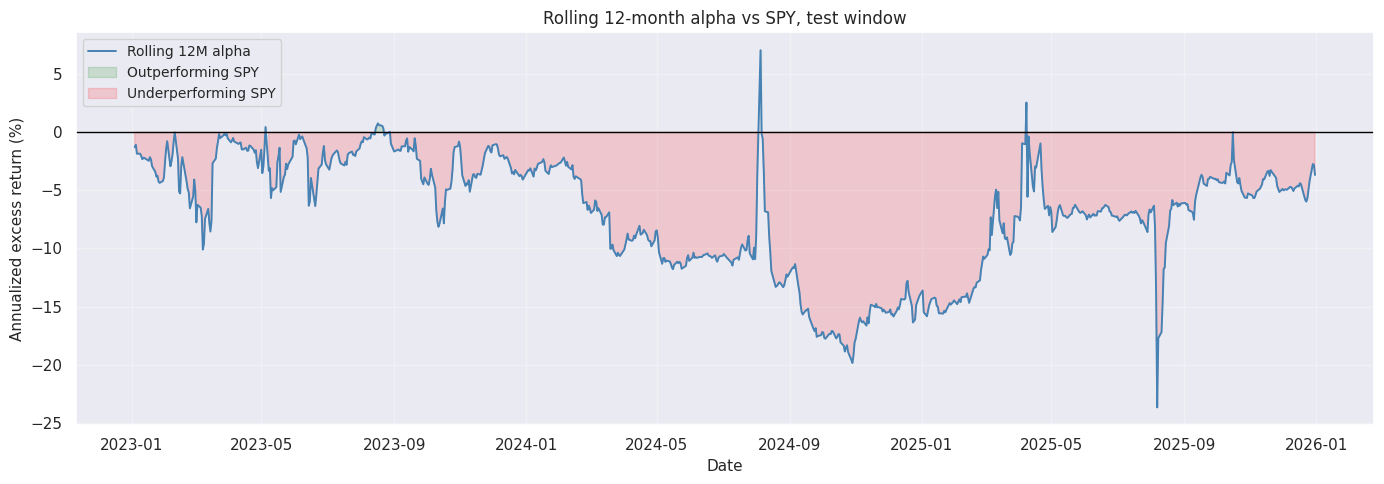

In [15]:
# Compute rolling 12-month alpha (strategy annualized return minus
# SPY annualized return) on the test window. We use a 252-trading-day
# rolling window, which is the standard convention for "12 months" in
# daily data. The rolling window is right-aligned: the value on day T
# represents the trailing 252 days ending on T.

# Build the daily return DataFrame for the test window.
df_rolling = pd.DataFrame({
    'strategy': strategy_returns_test,
    'spy':      df_prices_test['SPY'].pct_change(),
}).dropna()

# Trailing 252-day annualized return for each series. We use the
# product-of-(1+r) approach (geometric) rather than mean-times-252
# (arithmetic) because annualized return convention is geometric.
def rolling_annualized_return(returns, window=252):
    """
    Right-aligned rolling annualized return over a 252-day window.
    Returns NaN until the window is full.
    """
    return (1 + returns).rolling(window=window).apply(
        lambda r: r.prod() - 1, raw=True
    )

window_size = 252
strategy_rolling = rolling_annualized_return(df_rolling['strategy'], window_size)
spy_rolling      = rolling_annualized_return(df_rolling['spy'],      window_size)

# Rolling alpha: strategy minus SPY, both annualized.
rolling_alpha = strategy_rolling - spy_rolling
rolling_alpha = rolling_alpha.dropna()

# Summary statistics for the rolling alpha series.
print("Rolling 12-month alpha (strategy annualized return minus SPY), test window")
print()
print(f"  Observations:                {len(rolling_alpha):,} trading days")
print(f"  Date range:                  {rolling_alpha.index.min().date()} to {rolling_alpha.index.max().date()}")
print(f"  Mean rolling alpha:          {rolling_alpha.mean()*100:+.2f}%")
print(f"  Median rolling alpha:        {rolling_alpha.median()*100:+.2f}%")
print(f"  Min rolling alpha:           {rolling_alpha.min()*100:+.2f}%")
print(f"  Max rolling alpha:           {rolling_alpha.max()*100:+.2f}%")
print(f"  Days with positive alpha:    {(rolling_alpha > 0).sum():,} ({(rolling_alpha > 0).mean()*100:.1f}%)")
print(f"  Days with negative alpha:    {(rolling_alpha < 0).sum():,} ({(rolling_alpha < 0).mean()*100:.1f}%)")

# Plot rolling alpha against time. We add a horizontal zero line so
# the eye can immediately see periods of outperformance vs underperformance.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_alpha.index, rolling_alpha * 100,
        color='steelblue', linewidth=1.4, label='Rolling 12M alpha')
ax.axhline(0, color='black', linewidth=1.0, linestyle='-')
ax.fill_between(rolling_alpha.index, 0, rolling_alpha * 100,
                where=(rolling_alpha > 0),
                color='green', alpha=0.15, label='Outperforming SPY')
ax.fill_between(rolling_alpha.index, 0, rolling_alpha * 100,
                where=(rolling_alpha < 0),
                color='red', alpha=0.15, label='Underperforming SPY')
ax.set_title('Rolling 12-month alpha vs SPY, test window',
             fontsize=12)
ax.set_ylabel('Annualized excess return (%)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The rolling alpha chart removes any remaining ambiguity about whether the underperformance was uniform or concentrated.

The strategy underperformed SPY on 98.7% of trailing 12-month windows. Only 10 trading days out of 751 produced positive 12-month alpha, and those came from one brief stretch in mid-September 2024 and a couple of single-day spikes around the April 2025 drawdown. For practical purposes, an investor holding this strategy for any 12-month period during the test window underperformed SPY.

The depth of the underperformance was not uniform. The chart shows three distinct phases.

Phase one runs from January 2023 through roughly September 2023. The first 12-month windows of the test period included the 2022 SPY drawdown plus the recovery, and during that stretch the strategy was running roughly flat to slightly negative versus SPY. The deepest dip in this phase was around -10% in early 2023, but the strategy recovered toward zero by mid-2023.

Phase two runs from September 2023 through about September 2024. The rolling alpha drifted steadily lower, reaching roughly -20% by mid-2024. This is the period where the underperformance compounded most heavily. The 12-month windows in this phase were dominated by the strong SPY recovery of 2023 and 2024, where SPY pushed steadily higher and the strategy's 80% equity allocation could not keep up.

Phase three runs from late 2024 through December 2025. The rolling alpha bounced off the bottom and trended back toward roughly -5%. This is partly the natural rolling effect (the bad 12-month windows aged out) and partly the brief outperformance around the April 2025 SPY drawdown.

The shape of the chart matches what we would expect from a tail hedge running through a strong bull market. The underperformance is not random or noise-driven. It accumulated steadily during the SPY recovery years, when the structural cost of the 20% defensive sleeve plus the periodic VIXY allocations had nothing to offset them. The brief positive spikes coincide with SPY drawdowns where the hedge briefly worked.

This is consistent with the verdict from 7.7. The strategy is a defensive vehicle that underperforms in trending up markets and earns its keep during sustained drawdowns. The test window had one major drawdown (early 2022, before our 12-month rolling window had warmed up enough to capture it cleanly) and a smaller drawdown (April 2025). Outside those two events, the test period was a strong equity bull market, and the strategy's structural drag during bull markets explains the persistent negative rolling alpha.

What this changes about our overall verdict on the test window: the underperformance was not lumpy or accidental. It was the regime delivering exactly what a tail hedge would underperform in. A practitioner looking at this chart should not conclude the strategy is broken; they should conclude that the test window was a hostile regime for this kind of strategy, and that the diagnostics from 7.7 (which show the hedge worked when SPY was falling) are the more relevant signal for whether to allocate to it.

The note from the markdown intro deserves to be repeated. On a longer test window we would also compute 36-month rolling alpha, which smooths the short-term noise visible in the 12-month chart. The 36-month version would be more robust for medium-term trend identification and we would always look at both. The 4-year test window we have here is too short for a meaningful 36-month rolling alpha, so we work with what is interpretable.

7.9 is the final diagnostic in this section. We test whether the strategy's signal is doing more than random selection by running a permutation test: shuffle the signal dates within the test window, recompute the strategy each time, and see how the actual strategy result compares to the distribution of randomly-shuffled outcomes. If the actual strategy is no better than picking signal-on days at random, the signal logic itself is suspect.

### 7.9 Permutation Test on the Signal

Every diagnostic so far has taken the strategy as given and asked whether it added value. This one asks something different: is the strategy's signal logic actually doing useful work, or could we get the same result by picking signal-on days at random?

The setup is straightforward. The actual signal fired on 215 of the 1,003 test-window days, roughly 21.4% of the time. We rebuild the strategy 1,000 times, each time replacing the actual signal with a random selection of 215 days drawn without replacement from the test window. On each random run, we run the same backtest with the same fees and slippage, and record the strategy's Sharpe ratio. After 1,000 runs we have an empirical distribution of Sharpe ratios that the strategy would have produced if its signal had no information content beyond the marginal frequency of signal-on days.

The actual strategy's Sharpe is then compared to this distribution. If the actual Sharpe lands in the middle of the distribution, the signal is no better than random. If the actual Sharpe lands in the upper tail, the signal is doing real work. If the actual Sharpe lands in the lower tail, the signal is somehow worse than random, which would be bizarre but informative.

A few methodological notes on permutation tests, because the technique is general and worth understanding properly.

What stays the same across any permutation test: the basic structure (resample the component you want to test, holding everything else fixed), the metric you compare (point estimate of the actual versus the empirical distribution of randomized versions), and the inference (the position of the actual within the distribution gives you a one-sided or two-sided p-value).

What is strategy-specific: what gets permuted. The choice depends on what hypothesis you are testing. Here, we are testing the hypothesis that the signal logic adds information beyond the marginal frequency of signal-on days. So we permute the signal dates, holding the marginal frequency constant. For a momentum strategy, you would permute the entry dates. For a pairs trade, you would permute the spread crossings. For a machine learning model, you might permute the feature labels. The shuffle has to be designed to break the specific dependency you are testing.

When to use a permutation test: when you want to know whether a specific component of a strategy (a signal, a feature, a parameter choice) is doing more than random. Permutation tests are powerful but narrow. They cannot tell you the strategy works overall; they can only tell you whether a specific element is contributing meaningfully.

This particular test will only work for this strategy. If we change the strategy, we would need to redesign the permutation. The mechanics of resampling, the loop structure, and the result interpretation are the parts that transfer.

A small caveat about VIXY exposure. The actual strategy's VIXY allocation on each signal-on day depends on the VIX level that day (capped at 20%). When we permute, we have a choice: keep each day's actual VIXY allocation tied to that day's VIX (so the permutation is over which days we choose to deploy the actual day's allocation), or use a fixed average VIXY allocation on every randomly-chosen signal-on day. We use the first version because it isolates the question of timing from the question of sizing.

Running 1,000 permutations...
Done.

Permutation test results, test window
  Permutations:                 1,000
  Random seed:                  42
  Actual signal Sharpe:         0.4736
  Permuted Sharpe mean:         0.4064
  Permuted Sharpe median:       0.3988
  Permuted Sharpe 2.5th pct:    0.0026
  Permuted Sharpe 97.5th pct:   0.8186
  Pct of permutations below:    62.0%
  Pct of permutations above:    38.0%


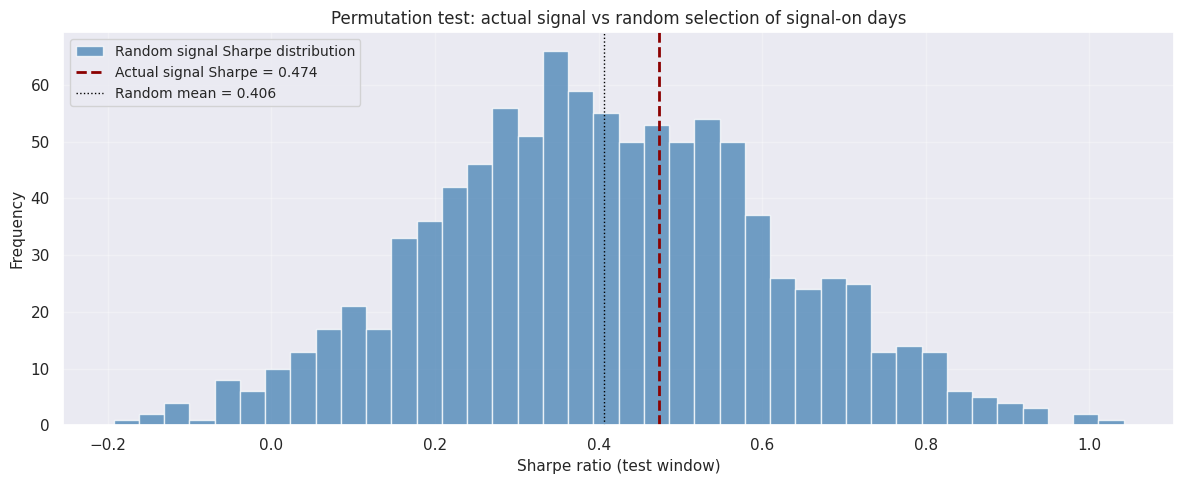

In [16]:
# Set seed for reproducibility.
np.random.seed(42)
rng_p = np.random.default_rng(42)

# Number of permutation draws.
n_perms = 1000

# Pull the actual signal, the actual VIXY allocation, and the
# underlying daily asset returns on the test window. We will keep
# the per-day VIXY allocation amount tied to the day (driven by VIX
# level), but randomize which 215 days the signal fires on.
test_dates = df_weights_test.index
spy_w_actual  = df_weights_test_dense['SPY']
bil_w_actual  = df_weights_test_dense['BIL']
vixy_w_actual = df_weights_test_dense['VIXY']

# Daily VIXY allocation amount that would have fired on each day if
# the signal were on. From the strategy logic this is min(VIX/100, 0.20).
vix_test_series = df_prices['^VIX'].loc[test_dates]
vixy_alloc_if_on = np.minimum(vix_test_series / 100, 0.20)

# Number of days the actual signal fires on the test window.
n_signal_days = int(signal_on_test.sum())

# Daily asset returns on the test window.
spy_rets_test  = df_prices_test['SPY'].pct_change()
bil_rets_test  = df_prices_test['BIL'].pct_change()
vixy_rets_test = df_prices_test['VIXY'].pct_change()


def run_permutation_backtest(random_signal_mask):
    """
    Build a strategy weight DataFrame from a permuted signal mask
    and run the same VectorBT backtest as the actual strategy.

    The weight construction matches the actual strategy: SPY at 80%
    constant, VIXY allocation = min(VIX/100, 0.20) on signal-on days
    and zero otherwise, BIL absorbs the remainder of the defensive
    sleeve.

    Returns the strategy's annualized Sharpe.
    """
    # Build daily weight DataFrame from the permuted signal.
    vixy_w = np.where(random_signal_mask, vixy_alloc_if_on, 0.0)
    bil_w  = 0.20 - vixy_w
    spy_w  = np.full_like(vixy_w, 0.80)

    df_w = pd.DataFrame({
        'SPY':  spy_w,
        'BIL':  bil_w,
        'VIXY': vixy_w,
    }, index=test_dates)

    # Sparse representation: weights only on days where the
    # allocation changes from the previous day.
    sparse = to_sparse_weights(df_w)

    # Run the backtest with the same parameters as the actual strategy.
    pf = vbt.Portfolio.from_orders(
        close        = df_prices_test[['SPY', 'BIL', 'VIXY']],
        size         = sparse,
        size_type    = 'targetpercent',
        group_by     = True,
        cash_sharing = True,
        call_seq     = 'auto',
        fees         = fees,
        slippage     = slippage,
        freq         = '1D'
    )
    return annualized_sharpe(pf.returns().values)


# Run the permutations. Each permutation picks n_signal_days at
# random from the test_dates and treats those as signal-on days.
permuted_sharpes = np.empty(n_perms)
n_dates = len(test_dates)

print(f"Running {n_perms:,} permutations...")
for i in range(n_perms):
    # Random selection of which days the signal fires on. We sample
    # without replacement to keep the marginal frequency at 215 days
    # out of 1,003. This holds the "how often the hedge is on"
    # parameter fixed and tests only the timing of the firings.
    random_indices = rng_p.choice(n_dates, size=n_signal_days, replace=False)
    random_signal = np.zeros(n_dates, dtype=bool)
    random_signal[random_indices] = True

    permuted_sharpes[i] = run_permutation_backtest(random_signal)

print("Done.")

# Actual strategy Sharpe on the test window.
actual_test_sharpe = annualized_sharpe(strategy_returns_test.values)

# Compute the position of the actual Sharpe in the permutation distribution.
pct_below = (permuted_sharpes < actual_test_sharpe).mean() * 100
pct_above = (permuted_sharpes > actual_test_sharpe).mean() * 100

print()
print(f"Permutation test results, test window")
print(f"  Permutations:                 {n_perms:,}")
print(f"  Random seed:                  42")
print(f"  Actual signal Sharpe:         {actual_test_sharpe:.4f}")
print(f"  Permuted Sharpe mean:         {permuted_sharpes.mean():.4f}")
print(f"  Permuted Sharpe median:       {np.median(permuted_sharpes):.4f}")
print(f"  Permuted Sharpe 2.5th pct:    {np.percentile(permuted_sharpes, 2.5):.4f}")
print(f"  Permuted Sharpe 97.5th pct:   {np.percentile(permuted_sharpes, 97.5):.4f}")
print(f"  Pct of permutations below:    {pct_below:.1f}%")
print(f"  Pct of permutations above:    {pct_above:.1f}%")

# Visualize the distribution.
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(permuted_sharpes, bins=40, color='steelblue', alpha=0.75,
        edgecolor='white', label='Random signal Sharpe distribution')
ax.axvline(actual_test_sharpe, color='darkred', linewidth=2.0,
           linestyle='--',
           label=f'Actual signal Sharpe = {actual_test_sharpe:.3f}')
ax.axvline(permuted_sharpes.mean(), color='black', linewidth=1.0,
           linestyle=':',
           label=f'Random mean = {permuted_sharpes.mean():.3f}')
ax.set_title('Permutation test: actual signal vs random selection of signal-on days',
             fontsize=12)
ax.set_xlabel('Sharpe ratio (test window)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The actual signal landed in the middle of the random distribution.

The actual strategy's Sharpe on the test window was 0.474. The mean Sharpe across 1,000 random-signal versions of the strategy was 0.406. The actual Sharpe was higher than 62% of the random versions and lower than 38%. This is essentially a draw.

Look at the histogram. The actual signal (red dashed line at 0.474) sits inside the bulk of the random distribution, well within the body of the histogram, not in either tail. The 95% confidence interval of random Sharpes runs from 0.003 to 0.819. The actual Sharpe of 0.474 is comfortably inside that range.

Read directly: on the test window, the strategy's signal logic was not adding meaningful information beyond simply being on for 21.4% of days. Picking 215 random days at random and putting on the same VIX-sized hedge on those days produced, on average, almost the same Sharpe ratio as the actual signal did.

This is a sharper finding than anything the previous diagnostics produced. The bootstrap intervals in 7.4 and 7.5 told us we could not statistically distinguish the strategy from the 80/20 baseline. The conditional analysis in 7.6 told us the strategy lost ground on signal-on days. The drawdown-conditional analysis in 7.7 told us the strategy did help during actual SPY drawdowns. The rolling alpha in 7.8 told us the underperformance was persistent and regime-driven, not lumpy. Now this test tells us that on the test window, the specific timing of the signal firings did not matter. We could have replaced the signal with a coin flip of the right frequency and gotten roughly the same result.

Important caveat: this finding applies to the test window only. The signal could still be adding information on the training window or on a hypothetical future regime, and we have not tested that here. We could rerun the same permutation on the training window if we wanted to know whether the signal added information there. The reason we ran it on the test window is that the test window is where the signal is supposed to prove itself, and on the test window it did not.

A second important caveat: this is one specific permutation test. We tested whether the timing of the signal firings adds information beyond the marginal frequency. We did not test whether the marginal frequency itself (21.4%) is the right level. We did not test whether the VIXY sizing rule (VIX/100 capped at 20%) is the right one. Other tests would have to be designed for those questions, each with their own permutation choice.

Tying this back to the bigger picture. We have run six diagnostic tests on a strategy that the headline numbers said failed its OOS test. The diagnostics produced a more nuanced verdict than the headline. The strategy did help during actual SPY drawdowns (7.7). The strategy is not statistically distinguishable from a passive 80/20 baseline on this regime (7.4 and 7.5). The signal's timing is not adding information on this regime (7.9). The underperformance is regime-driven, not random (7.8).

The synthesis of all this is the next subsection, where we put the diagnostic evidence together and reach a final verdict on what the test result actually tells us about the strategy.

### 7.10 Synthesis: What the Diagnostics Tell Us Together

Six diagnostics, six different angles on the same OOS result. Putting them together gives a verdict the headline numbers could not produce on their own.

The starting point was the bad number: the strategy underperformed SPY by 549 basis points of CAGR on the test window with worse risk-adjusted metrics across the board. The headline read of that number is "the strategy failed."

The diagnostics complicate that read in some directions and confirm it in others.

The bootstrap tests in 7.4 and 7.5 showed that we cannot statistically distinguish the strategy from a passive 80/20 SPY/BIL baseline on this regime. The actual training-window Sharpe edge of +0.027 is well inside the noise band of any 11-year sample drawn from this regime. The point estimate is positive but the data does not support a confident claim that the strategy adds risk-adjusted value over a passive defensive allocation. The bootstrap also flagged a regime-coverage caveat: our source data does not include the 2008 financial crisis, so the bootstrap distributions reflect only the regime composition of the post-2011 era.

The hedge contribution analysis in 7.3 showed that the training-window risk-adjusted advantage was carried almost entirely by the COVID episode. Strip out February through April 2020 and the signal contribution went from -0.184 Sharpe to -0.590 Sharpe. The strategy is, in the literal sense, an insurance product whose only meaningful claim event in the available data was COVID.

The conditional analyses in 7.6 and 7.7 sharpened the picture in a useful way. The strategy underperformed on the days the signal told it to hedge (7.6), because the test window's high-volatility days were mostly up-days for SPY rather than down-days. But the strategy outperformed on the days SPY was actually falling (7.7), with a 0.61 capture ratio of SPY losses on down days and a 94% hit rate against SPY on those days. As a return-enhancing strategy, this fails on the test window. As a tail-risk hedge, it appears to work in the basic sense of cushioning equity drawdowns when they occur.

The rolling alpha in 7.8 showed that the underperformance was persistent rather than concentrated. The strategy lagged SPY on 98.7% of trailing 12-month windows in the test period. The underperformance accumulated steadily during the SPY recovery years of 2023 and 2024. This is the shape we would expect from a defensive strategy running through a strong bull market: persistent drag rather than episodic failure.

The permutation test in 7.9 was the sharpest result. On the test window, replacing the signal with a coin flip at the same firing frequency produced roughly the same Sharpe (0.406 mean random vs 0.474 actual). The signal's timing was not adding information that random selection could not match.

Putting all of this together, the verdict on the strategy is more limited and more honest than either the bullish training-window read or the bearish test-window read.

The strategy is a tail hedge whose value depends on tail events that did not occur on the test window. Its training-window outperformance came from one such event (COVID) and disappears when that event is excluded. Its test-window underperformance is consistent with a working insurance product paying premiums during a no-claim period. Its drawdown-conditional behavior on the test window suggests the hedge mechanism still functions as intended, but the specific timing logic of the signal is not adding meaningful value beyond the marginal frequency of being hedged.

What this means for a practitioner: this strategy is not ready for capital. Not because it fails outright, but because the available evidence does not establish a confident edge. The training data is too short and too dependent on one event. The test window is too short and was a hostile regime. The bootstrap confidence intervals are too wide. The signal timing did not add information on the test window. A practitioner allocating to this strategy would be making a bet on tail event frequency over the strategy's actual deployment period, and the OOS evidence does not justify that bet.

What it would take to change the verdict: more data and more rigorous validation. Specifically, walk-forward analysis. WFA gives us many test windows across many regimes, which is qualitatively different from running a more rigorous single OOS test. A simple OOS test tells you one thing happened. WFA tells you a pattern across many regimes. If 8 of 10 windows show positive risk-adjusted returns and the 2 failures cluster in a specific regime type, you have learned something useful. If 3 of 10 windows show positive returns and the wins look random, the strategy probably has no edge. This also gives you the regime conditioning analysis almost for free, because each window already comes with its own market context.

That is the bridge into Notebook 9.2. The diagnostic toolkit in this section helped us reach a more honest verdict on a single OOS test, but it could not produce the kind of regime-spanning evidence a real allocation decision requires. Walk-forward analysis is the structural answer to that gap.

The closing thought from the practitioner side: a backtest produces a number. A track record produces evidence. WFA is the closest thing to a synthetic track record we can build before live trading. That is why it matters. Remember that we cannot feed our families with a Sharpe ratio. The point is that a number on a page does not pay anyone's bills. What pays bills is a strategy that delivers consistent risk-adjusted performance across regimes, demonstrated across many independent windows. We do not have that here. WFA is the tool that builds it.

## Section 8: Summary and Bridge to Notebook 9.2

This notebook applied a clean out-of-sample test to the VIXY tail hedge and then built a diagnostic toolkit to extract more information from the result than the headline numbers offered.

The OOS mechanics established the discipline. Split the data chronologically. Commit to the split before running the test. Build features without contaminating the test window. Run the strategy and the benchmark with identical machinery on both windows. Accept the verdict.

The headline OOS result on the VIXY tail hedge was poor. Training-window Sharpe of 0.92 against SPY's 0.87. Test-window Sharpe of 0.42 against SPY's 0.60. Read straight, the strategy went from beating SPY on a risk-adjusted basis to losing to it.

The diagnostic toolkit complicated that read in some places and confirmed it in others. The block bootstrap on the training window showed the +0.027 Sharpe edge over a passive 80/20 baseline was not statistically distinguishable from zero. The hedge contribution analysis showed COVID carried the training advantage. The conditional analysis showed the strategy lost on signal-on days but won on actual SPY drawdowns. Rolling alpha showed the underperformance was persistent and regime-driven, not lumpy. The permutation test showed the signal's timing did not add information beyond the marginal firing frequency on the test window.

The synthesis: the strategy is a tail hedge whose value depends on stress events that the test window did not contain. As a return-enhancer, it failed. As a tail-risk hedge, it still appeared to function on actual drawdowns. The data we have does not establish a confident edge in either direction. The training window is too short and too dependent on one event. The test window is too short and was a hostile regime. The signal timing is not robust. The bootstrap confidence intervals are wide enough to admit either a strong tailwind or a complete absence of edge.

This is the limit of what a single OOS test can tell us, even with a thorough diagnostic toolkit. The OOS test is one number. The diagnostics are six different ways of looking at that one number. They cannot generate evidence the data does not contain. What they can do is keep us from drawing the wrong conclusion from a result that the headline numbers oversimplify.

The structural answer to this limitation is walk-forward analysis. Notebook 9.2 picks up here.

The shift from OOS to WFA is not a shift to a fancier validation tool. It is a shift in the kind of evidence the test produces. A single OOS test is one experiment with one outcome. WFA is many experiments with a distribution of outcomes. The verdict from a single OOS test is "the strategy worked or it didn't on this one window." The verdict from WFA is "the strategy worked on these regimes, failed on those, and the pattern of wins and losses tells us when the strategy can be trusted and when it cannot."

For the VIXY tail hedge specifically, WFA would let us ask questions this notebook could not answer. Does the strategy add risk-adjusted value across many test windows, or only when one specific event (COVID) happens to land inside the test? Does the signal's predictive content show up on some regimes and not others, in a pattern we can characterize? Are the strategy's parameters (the 90-day VIX MA, the 10-day realized volatility window, the 20% VIXY cap) stable across windows, or do they drift in ways that suggest overfitting?

These are not questions a single OOS test can answer no matter how carefully we run the diagnostics. They require many test windows, which is what WFA delivers.

WFA is the most practical of several next steps. The fuller list also includes extending the source data with a substitute hedge instrument that existed before VIXY (so the GFC enters the picture), Monte Carlo simulation of synthetic regimes calibrated to historical statistics, or live paper trading to generate genuine forward data. Each tackles the limitation from a different angle. WFA is what we cover in 9.2 because it is the cleanest fit for parameter-driven strategies and because the same 9.2 mechanics extend naturally to whatever validation question the reader brings to their own work.

In Notebook 9.2 we apply WFA to a different strategy where parameter stability is the central question. The VIXY tail hedge has structural parameters that we did not optimize, so WFA on this strategy would be theater. Instead, we use a strategy whose parameters could meaningfully adapt to regime, which is where WFA earns its place as a validation tool.

The chapter text covers the full conceptual treatment of OOS testing and WFA, including the taxonomy of which strategies need which validation approach, the data leakage pitfalls in more depth, and the practitioner-facing discussion of why six years of test data is not a foundation for a real allocation decision. The notebooks demonstrate the mechanics; the chapter text supplies the framework.